In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =21 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 21  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 21

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c21_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c21patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

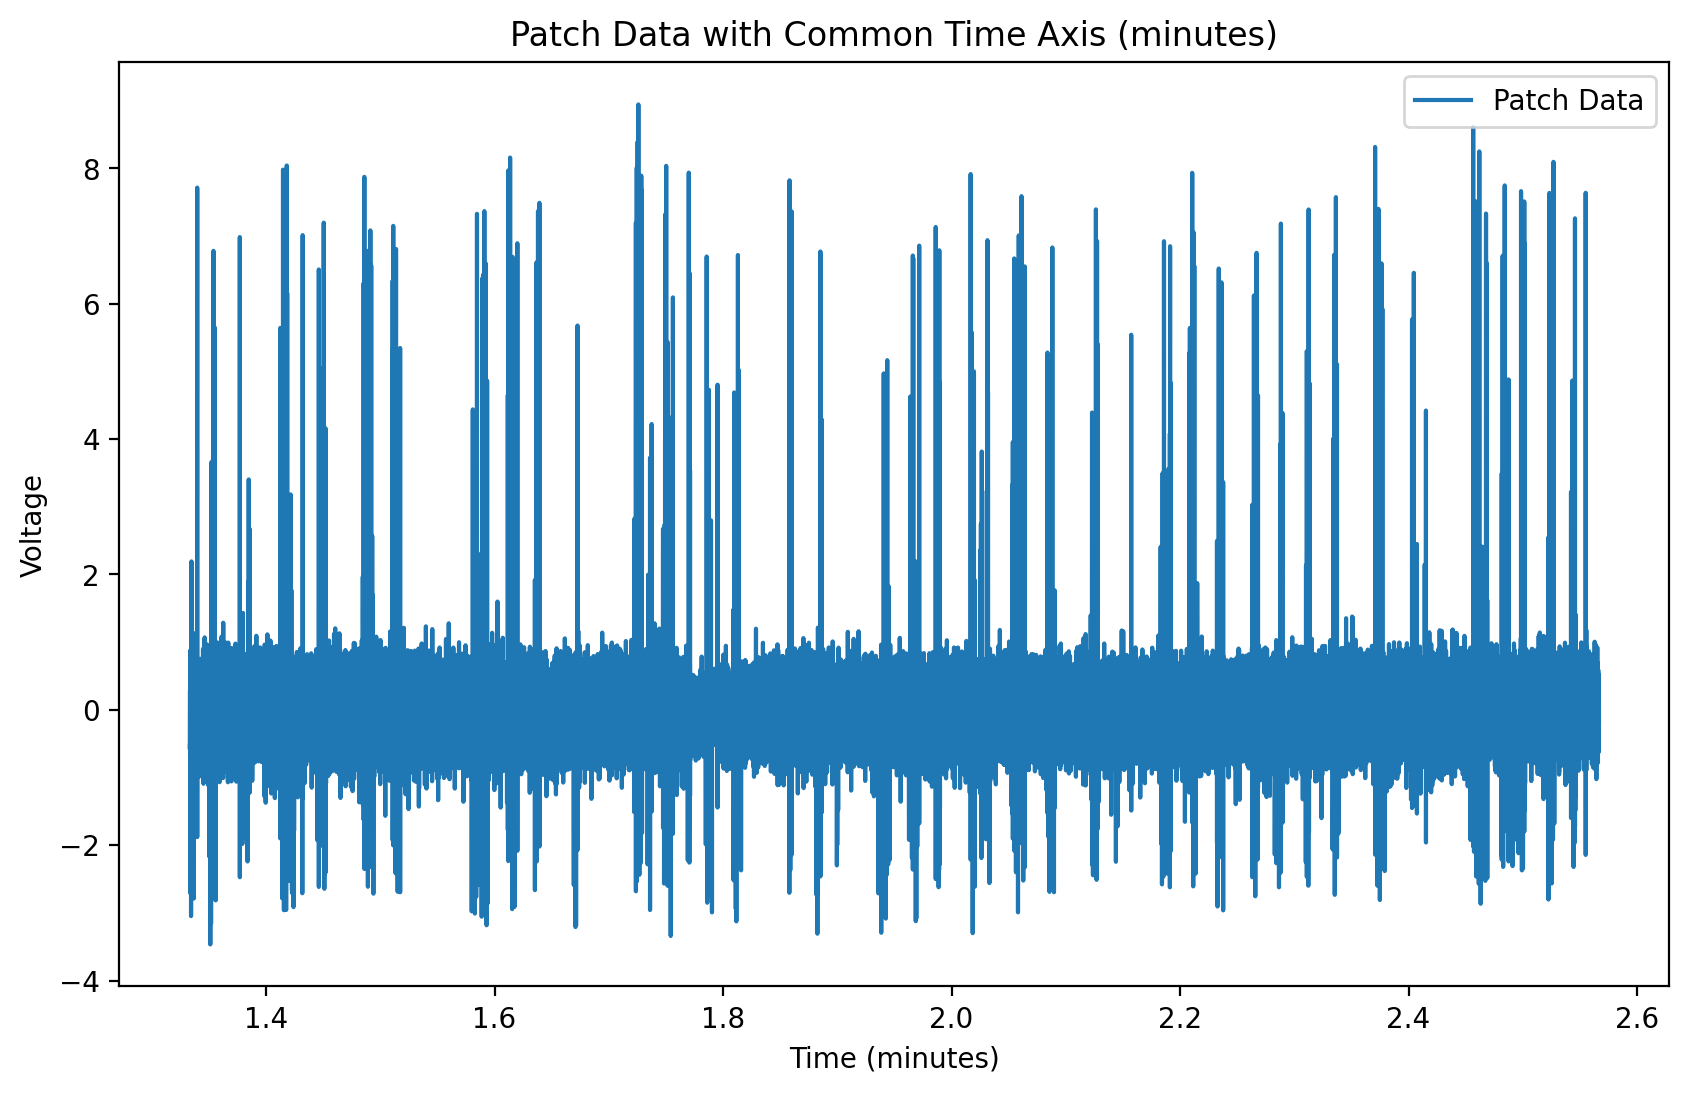

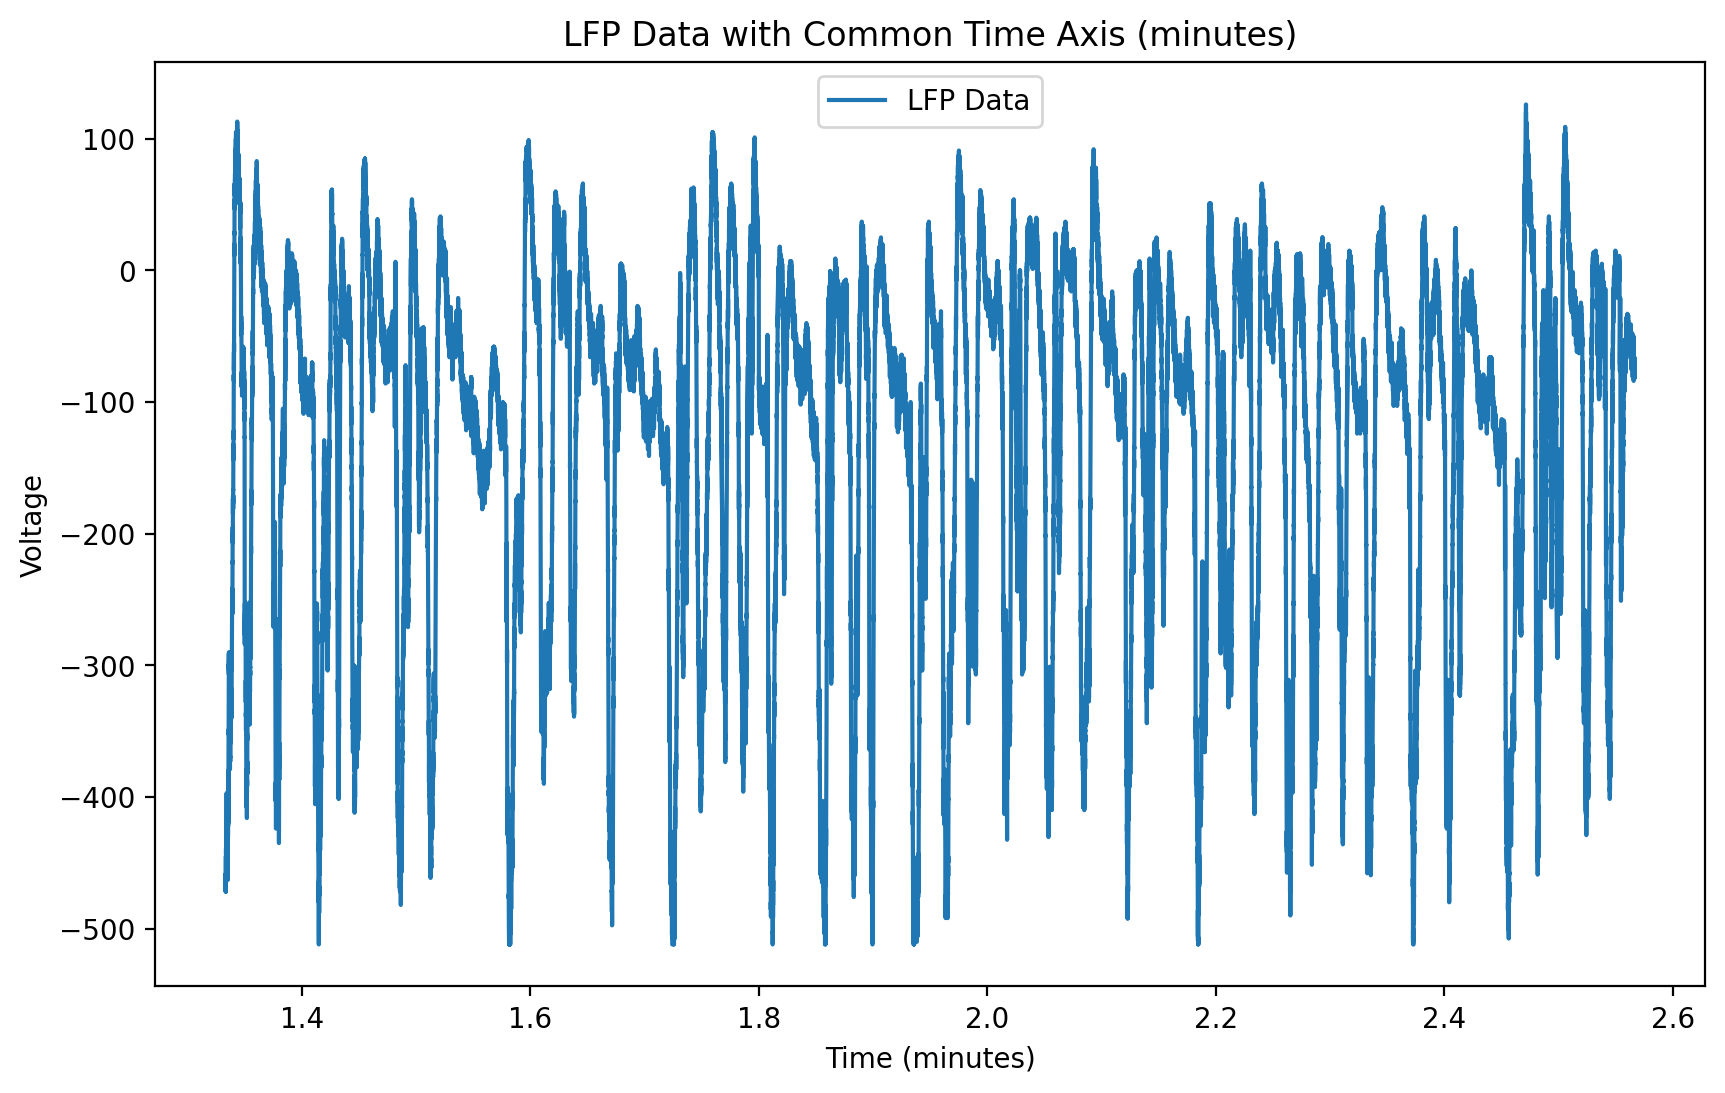

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

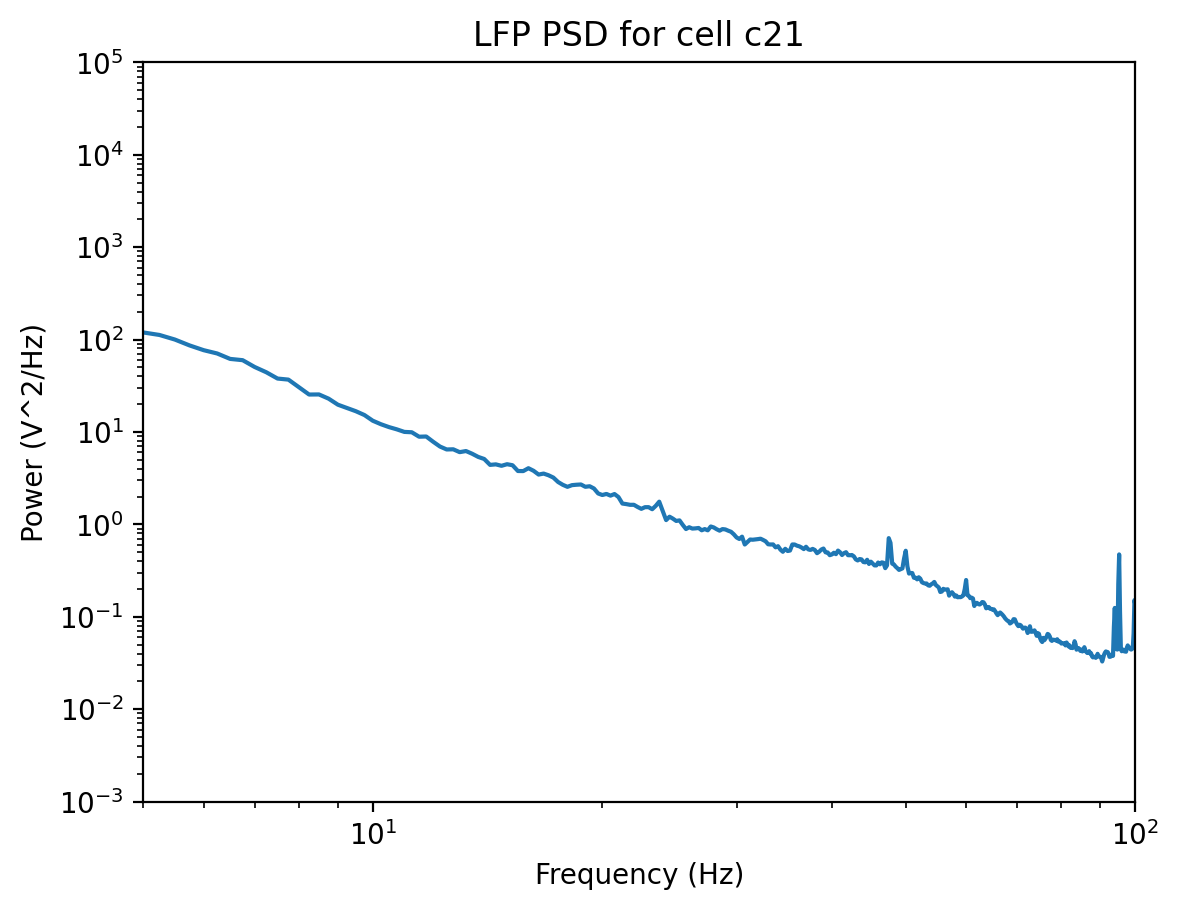

In [7]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (5, 10e1)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


In [8]:
bands = Bands({'gamma' : [30, 60]})

In [9]:
decim_factor = 10

###### SLIDING WINDOWS APPROACH - Multitaper

In [10]:
model_mt, freqs_mt, window_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    window_length_sec = 0.1,
    freq_range = (5,90),
    fs=lfp_fs,
    method="multitaper",
    decim_factor = decim_factor
)

summary_df_multitaper = model_mt.to_df()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Running group fits.: 100%|███████████| 270012/270012 [13:30:45<00:00,  5.55it/s]


                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                Number of time windows fit: 270012                                
                                                                                                  
                        The model was run on the frequency range 5 - 90 Hz                        
                                 Frequency Resolution is 0.33 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

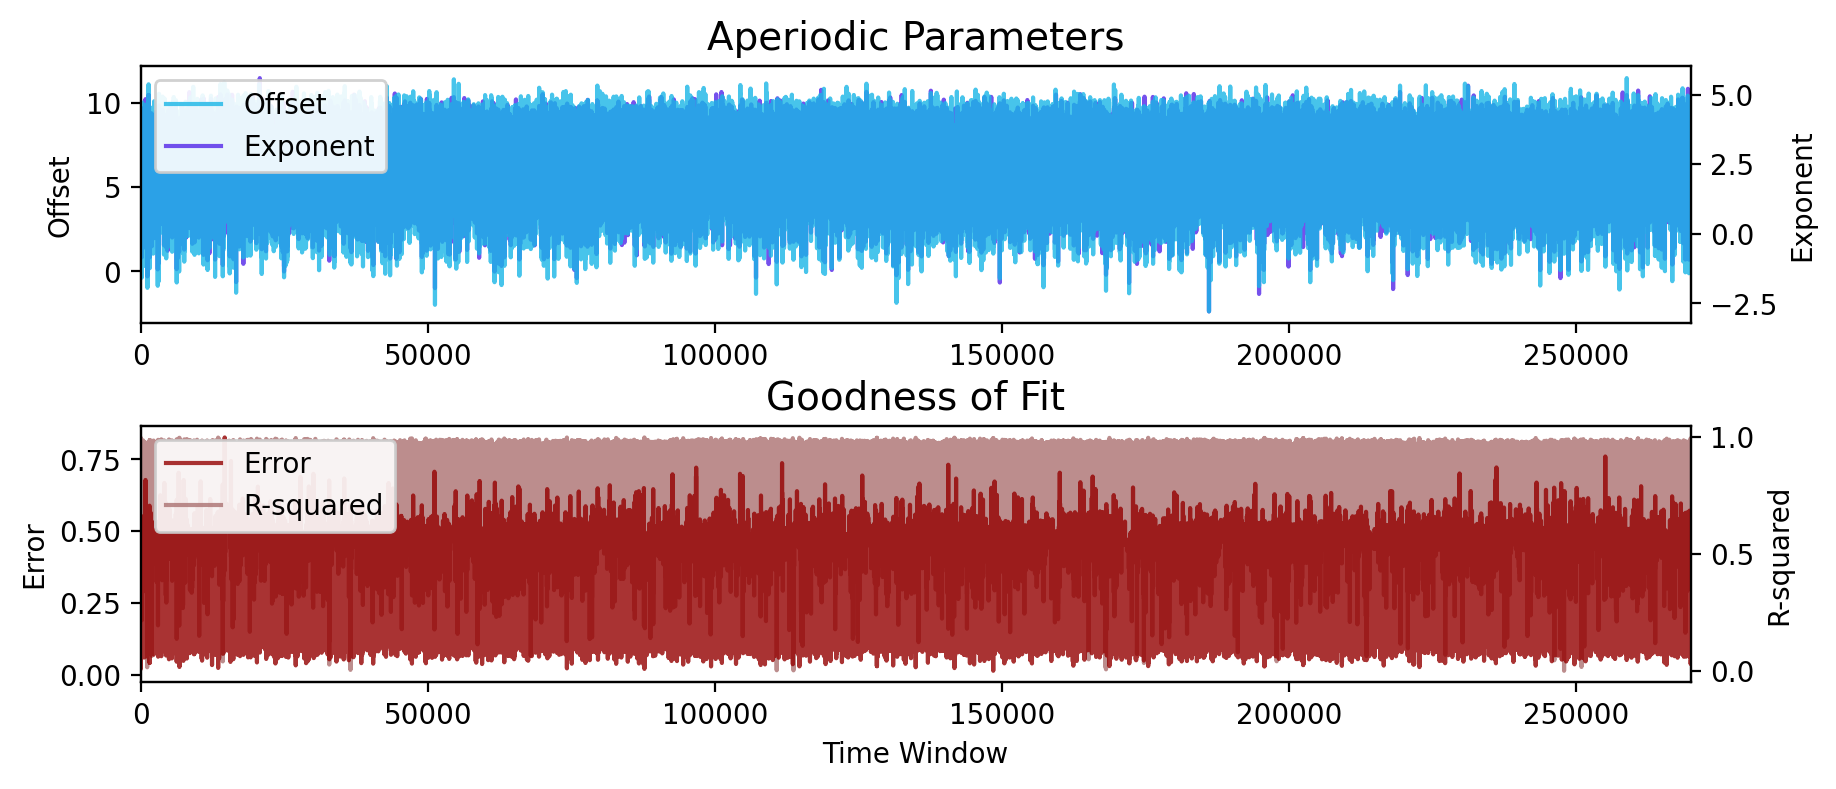

In [11]:
#model_mt.report(peak_org=bands)
model_mt.print_results()
model_mt.plot(peak_org=bands)
#try plot and print results - to avoid re-fitting??

In [12]:
#save as pickles 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_model_mt.pkl', 'wb') as file:
    pickle.dump(model_mt, file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_freqs_mt.pkl', 'wb') as file:
    pickle.dump(freqs_mt, file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_window_times_mt.pkl', 'wb') as file:
    pickle.dump(window_times_mt, file)

In [13]:
"""
#open pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_model_mt.pkl', 'rb') as file:
    model_mt = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_freqs_mt.pkl', 'rb') as file:
    freqs_mt = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_window_times_mt.pkl', 'rb') as file:
    window_times_mt = pickle.load(file)"""

"\n#open pickle\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_model_mt.pkl', 'rb') as file:\n    model_mt = pickle.load(file)\n\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_freqs_mt.pkl', 'rb') as file:\n    freqs_mt = pickle.load(file)\n\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/mtc21_window_times_mt.pkl', 'rb') as file:\n    window_times_mt = pickle.load(file)"

In [14]:
# Existing summary from specparam (offset, exponent, r_squared, error, n_peaks, etc.)
summary_df_multitaper = model_mt.to_df().reset_index(drop=True)



## STEP 2: Get AUC gamma (subtract off the aperiodic exponent from the raw spectrum)

In [15]:
#compute gamma AUC + exponent per window 
specp_auc_df = gamma_auc_and_exponent_per_window(model_mt, band=(25, 60), space="log")

Computing gamma AUC + exponent:   0%|          | 0/270012 [00:00<?, ?it/s]

In [16]:
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_auc_df.pkl', 'wb') as file:
    pickle.dump(specp_auc_df, file)

In [18]:
#open pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_auc_df.pkl', 'rb') as file:
    specp_auc_df = pickle.load(file)

In [19]:
specp_auc_df

,win_idx,gamma_auc,aperiodic_exponent,r_squared
0,0,2.871040,2.049845,0.979282
1,1,2.646765,1.959880,0.997009
2,2,3.003217,2.096460,0.995263
3,3,2.871822,2.006079,0.989938
4,4,3.846784,1.987001,0.986693
...,...,...,...,...
190239,270007,4.620953,2.200579,0.983618
190240,270008,3.108407,2.115581,0.987202
190241,270009,3.322348,2.028340,0.994372
190242,270010,3.935599,2.076595,0.990846


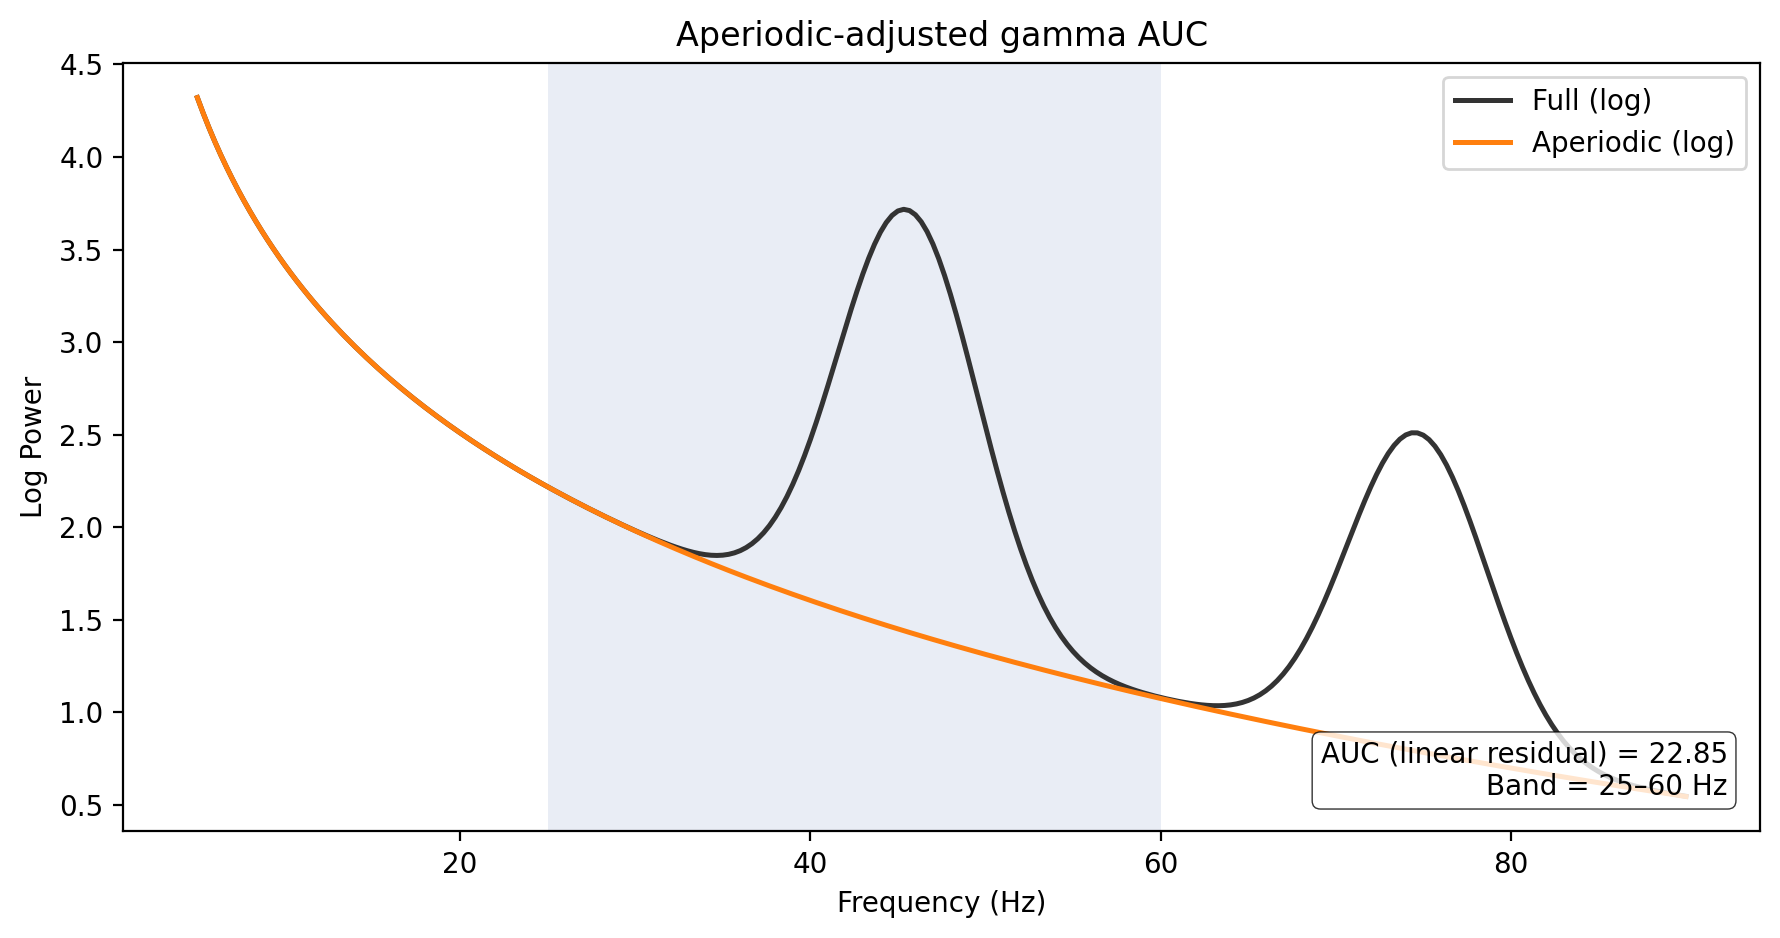

In [20]:
#Show example of process for one window idx
auc_val = plot_spectra_and_auc(
    model_mt,
    win_idx=30604,
    band=(25, 60),
    freq_range=(1, 90),   # optional, for display only
    title="Aperiodic-adjusted gamma AUC"
)


Aggregating spectra:   0%|          | 0/1500 [00:00<?, ?it/s]

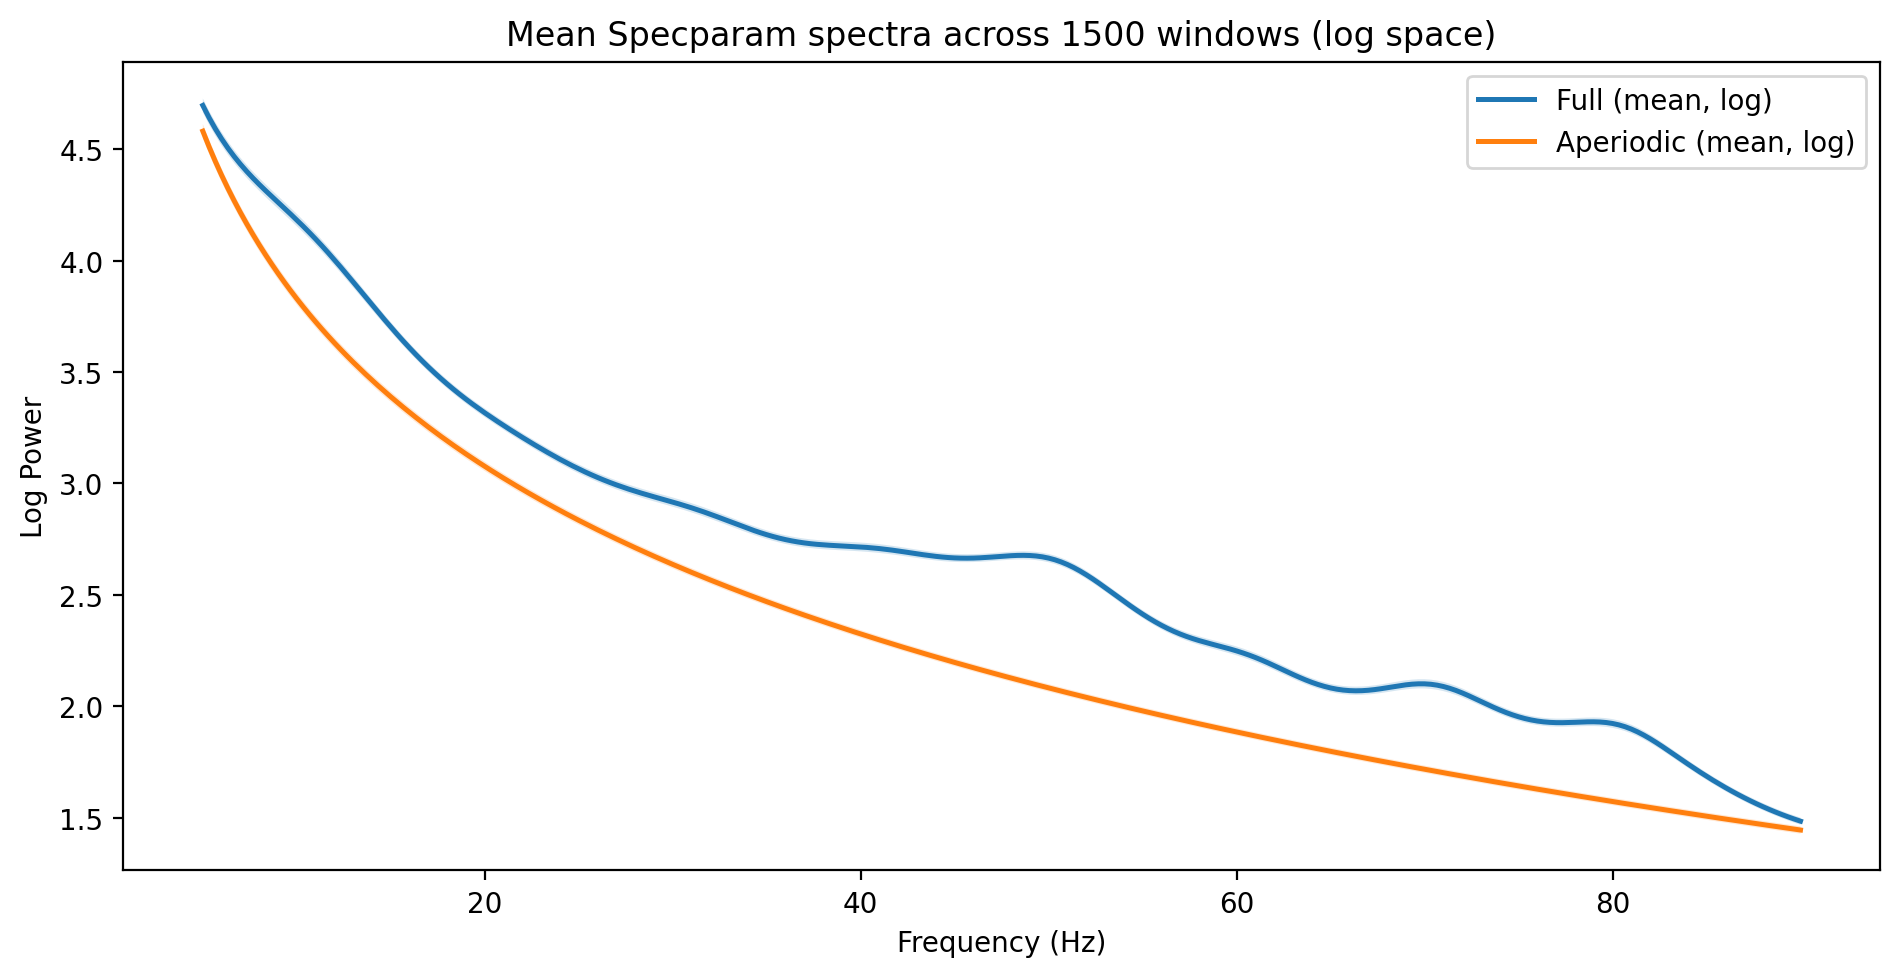

In [21]:
plot_mean_spectra_fast(model_mt, max_windows=1500)


## STEP 3: Detect spikes from patch data

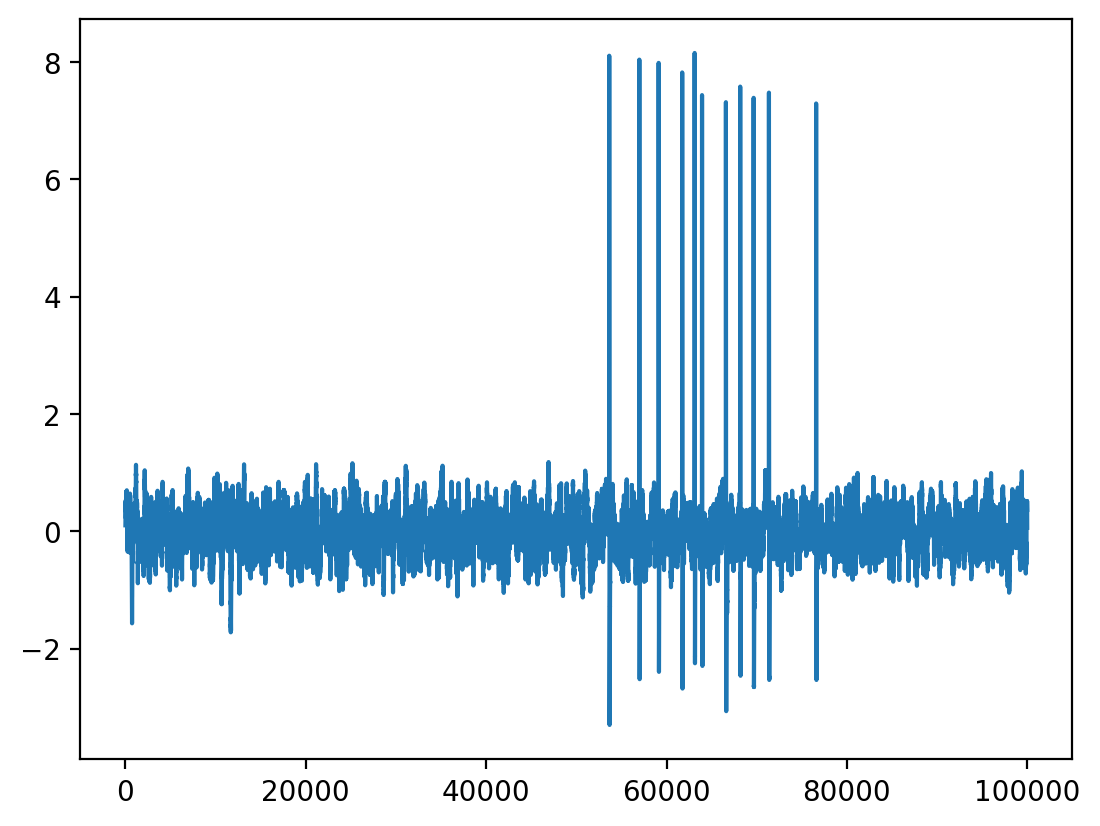

In [22]:
plt.plot(patch_filt[:100000] )

In [26]:



#threshold in mVs
sp = Spike(thresh_amp=4, window_length=(5., 5.), smooth_frac=.01)

In [27]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/861 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


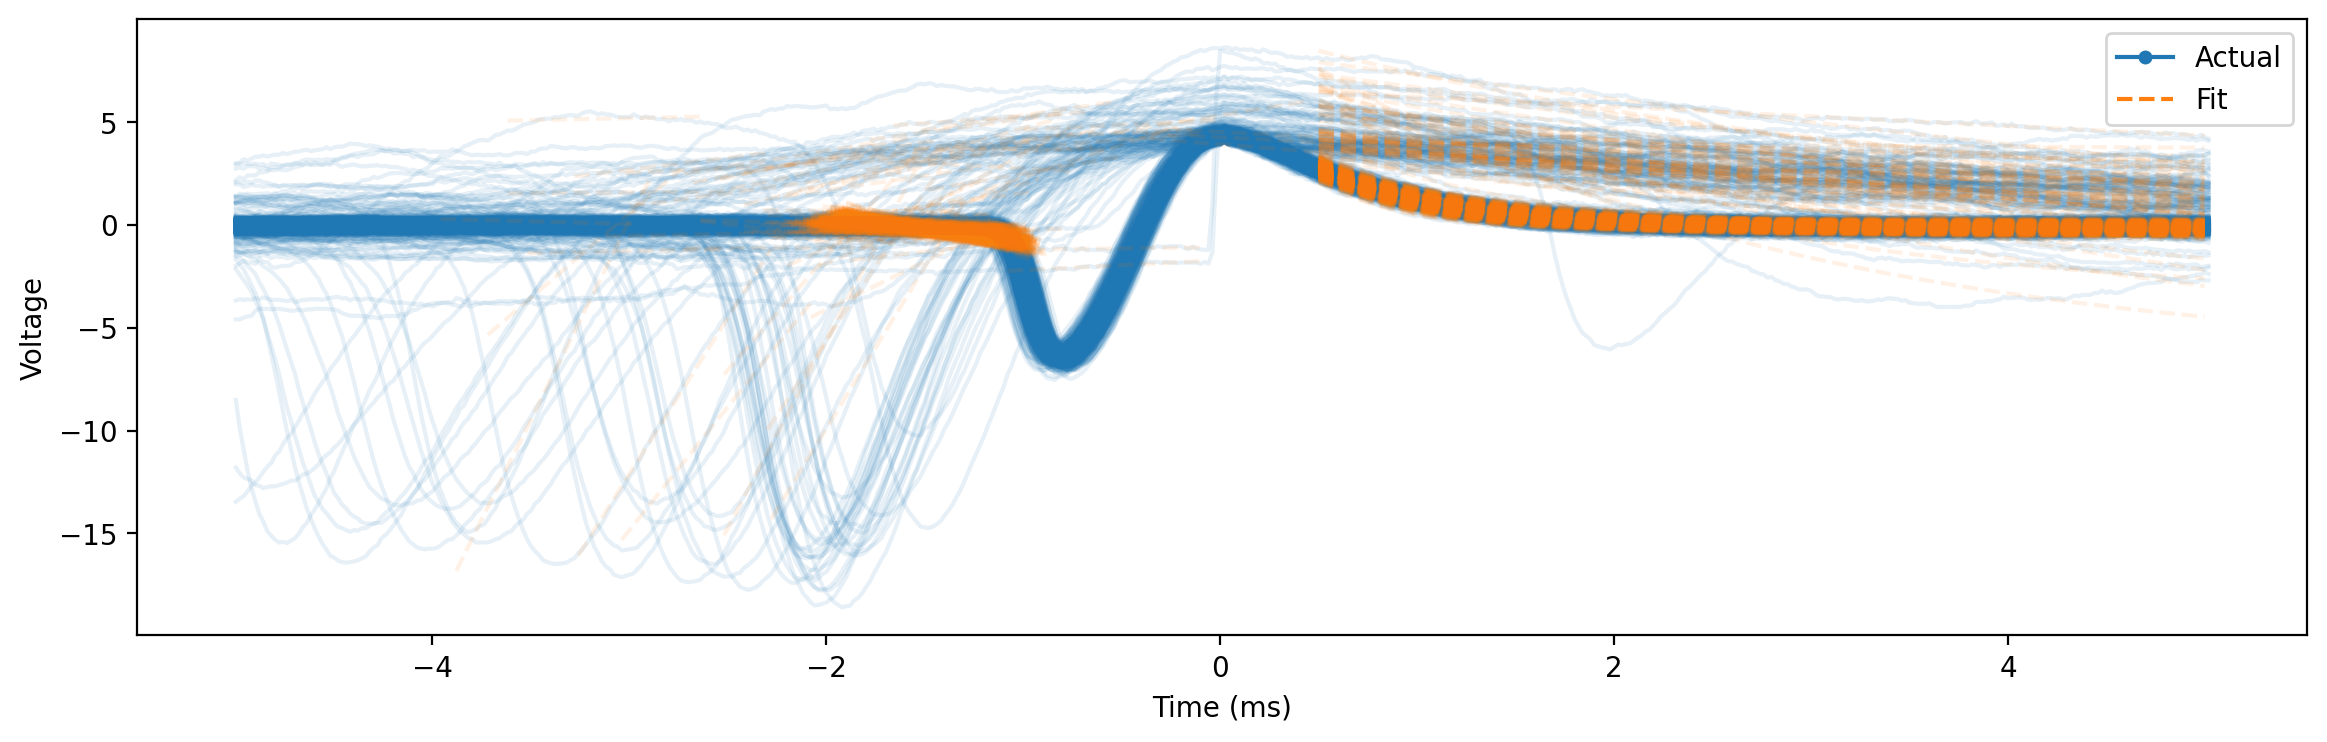

In [28]:
sp.plot()

### Filter spikes 

In [29]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [30]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [31]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
1,1.416220,0.52,5.370863,6.295294,0.60,0.043751,0.015726,-100.000000,2.219167,13343768,2.667479e+05,0
13,1.533453,1.72,3.874037,4.667276,0.82,0.090837,0.329459,1.627345,1.488625,13489994,2.696710e+05,1
36,2.366371,1.42,3.010957,4.096517,1.54,0.013247,0.324193,1.731115,1.623455,13637202,2.726137e+05,2
41,2.587793,0.80,4.747070,5.018727,0.50,-0.078035,0.237210,1.966579,1.877509,13676577,2.734009e+05,3
43,11.048626,1.52,2.315093,4.528403,2.92,0.091947,0.133589,1.852847,1.768579,13685862,2.735865e+05,4
...,...,...,...,...,...,...,...,...,...,...,...,...
852,-0.263089,1.10,-0.346746,4.291560,1.02,0.152129,1.399263,-0.280565,1.397037,53923228,1.077949e+06,503
853,-1.365464,0.98,-3.484229,4.112964,2.36,0.165741,1.634414,-0.357630,1.881975,53924476,1.077974e+06,504
854,-0.969500,0.94,-2.524469,4.160575,1.56,0.229697,1.769301,-0.327425,1.547813,53928288,1.078051e+06,505
856,-1.659589,0.86,-4.149963,4.181082,3.96,0.242676,1.602404,-0.350285,1.522758,53932402,1.078133e+06,506


### Get spike times


In [32]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 4: Get avg waveform and for every spike, calculate error (aligned to peak)

In [33]:
#get root mean squared errors
errs = spike_waveform_errors(sp, metric="rmse") 


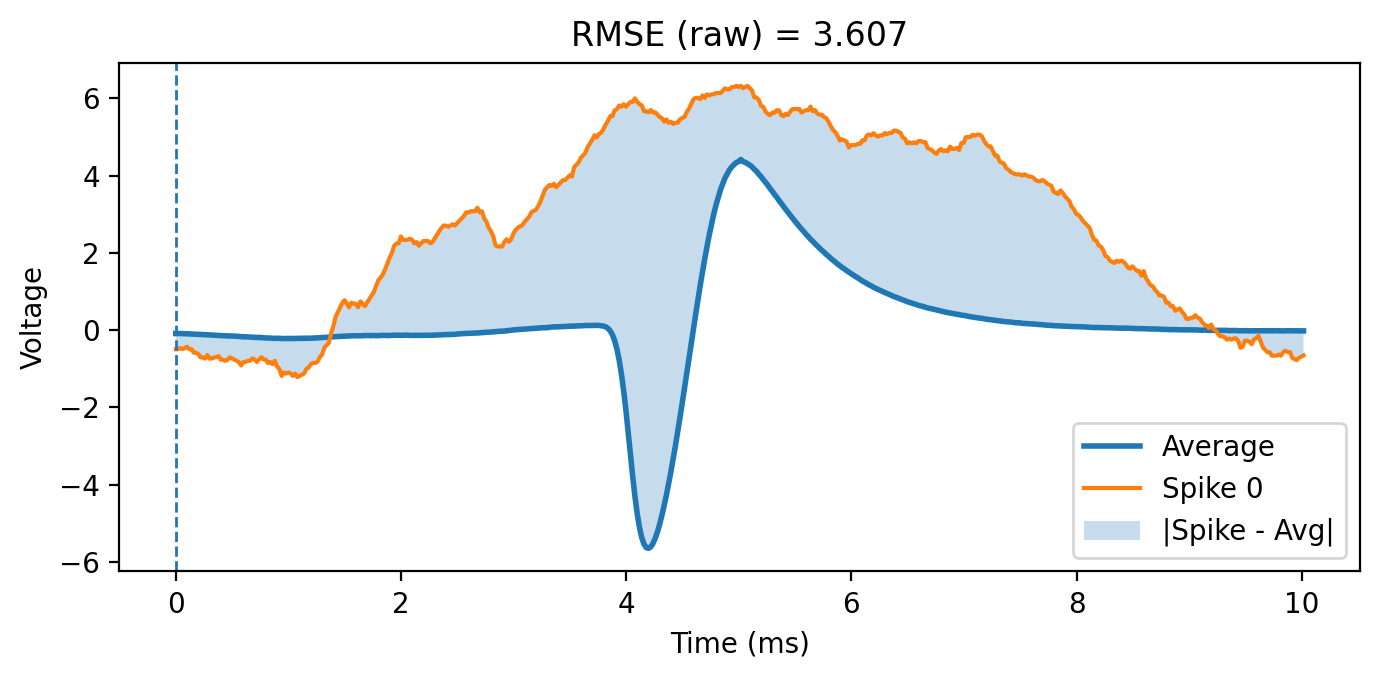

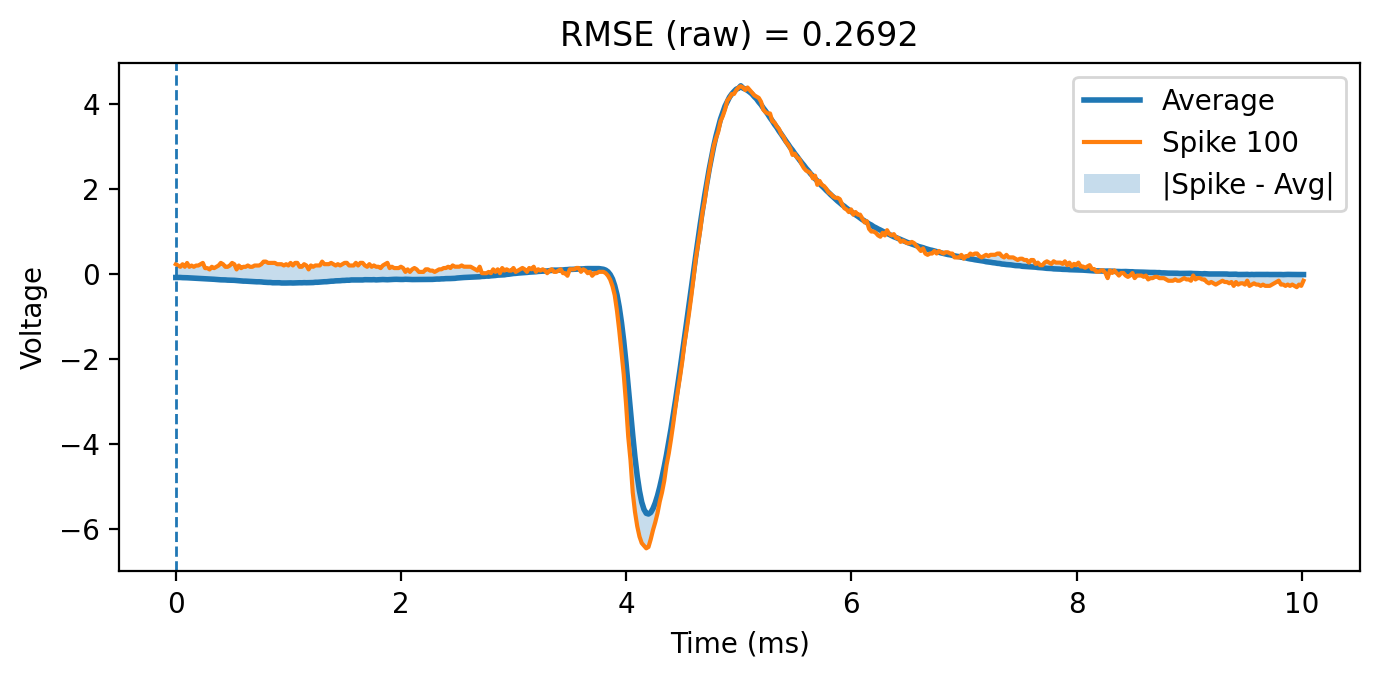

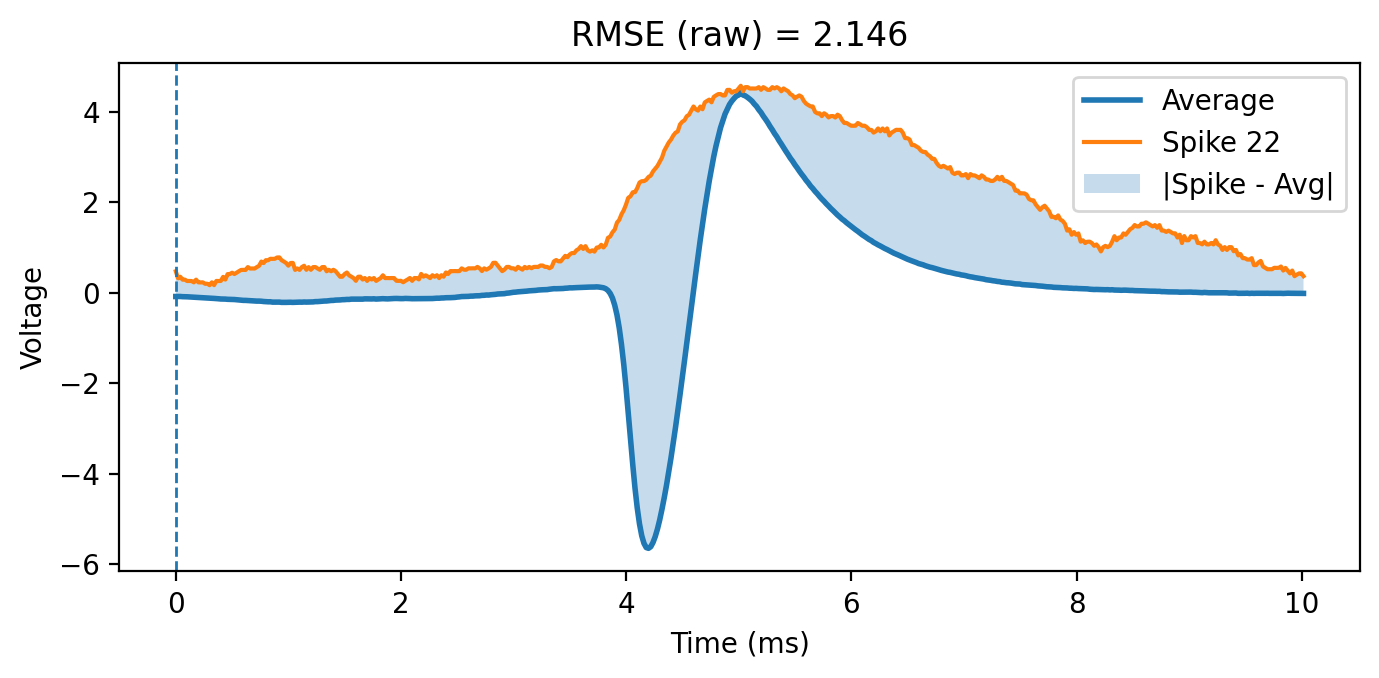

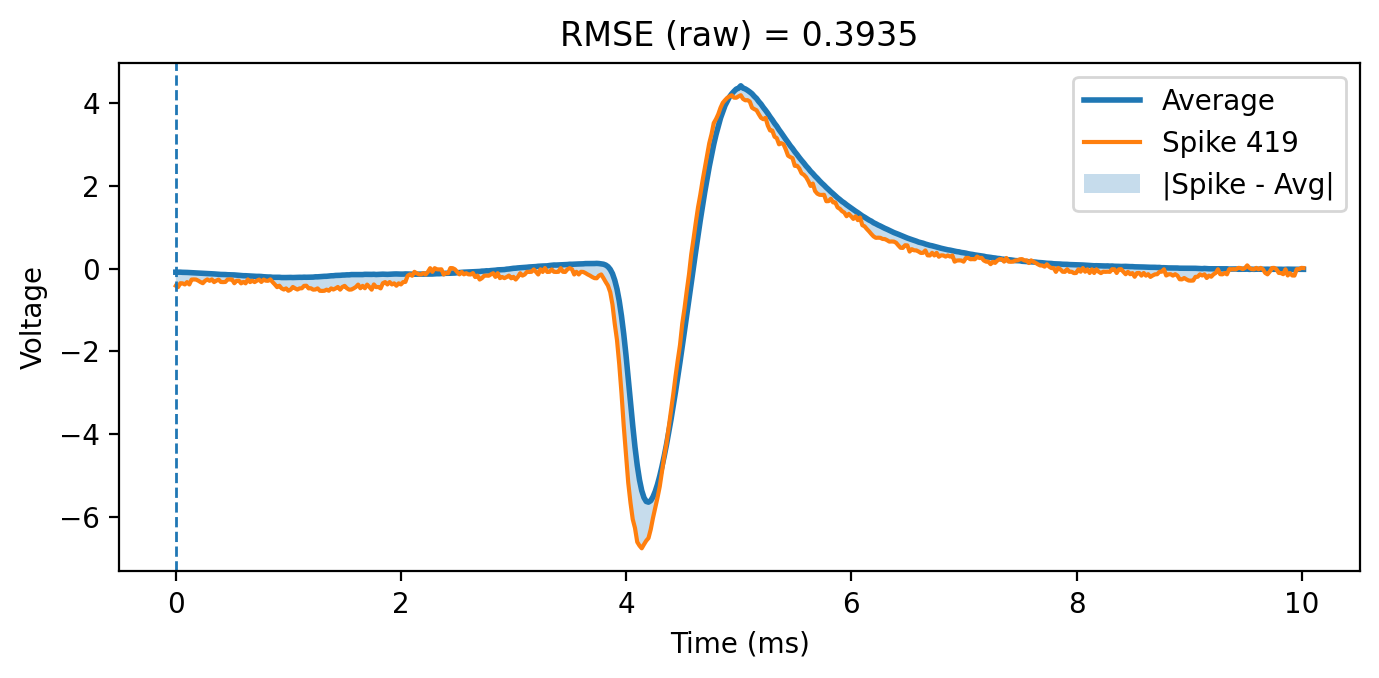

In [34]:
#Examples
e = visualize_spike_error(sp, spike_idx=0, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=100, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=22, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=419, metric="rmse", show_residual=True)


## STEP 4: Map spikes to windows and create df with spike error, LFP AUC and aperiodic exponent

In [35]:
#generate df with spike waveform errors, lfp window auc and aperiodic exponent
spike_lfp_df = make_spike_waveform_error_and_auc_df(errs, df_features, window_times_mt, lfp_fs, specp_auc_df)


In [36]:
spike_lfp_df

,spk_id,spk_times_ms,wf_error,win_idx,gamma_auc,aperiodic_exponent
0,0,2.667479e+05,3.606945,66686.0,NaN,NaN
1,1,2.696710e+05,5.308446,67417.0,15.540539,3.599550
2,2,2.726137e+05,5.096507,68153.0,7.675628,1.925618
3,3,2.734009e+05,5.370463,68350.0,20.957855,2.347222
4,4,2.735865e+05,4.994218,68396.0,23.834440,2.149321
...,...,...,...,...,...,...
503,503,1.077949e+06,0.328527,269487.0,18.256562,1.496351
504,504,1.077974e+06,0.435337,269493.0,33.569279,3.286082
505,505,1.078051e+06,0.404213,269512.0,17.113340,3.107944
506,506,1.078133e+06,0.531411,269533.0,4.719227,4.618236


Text(0, 0.5, 'gamma auc')

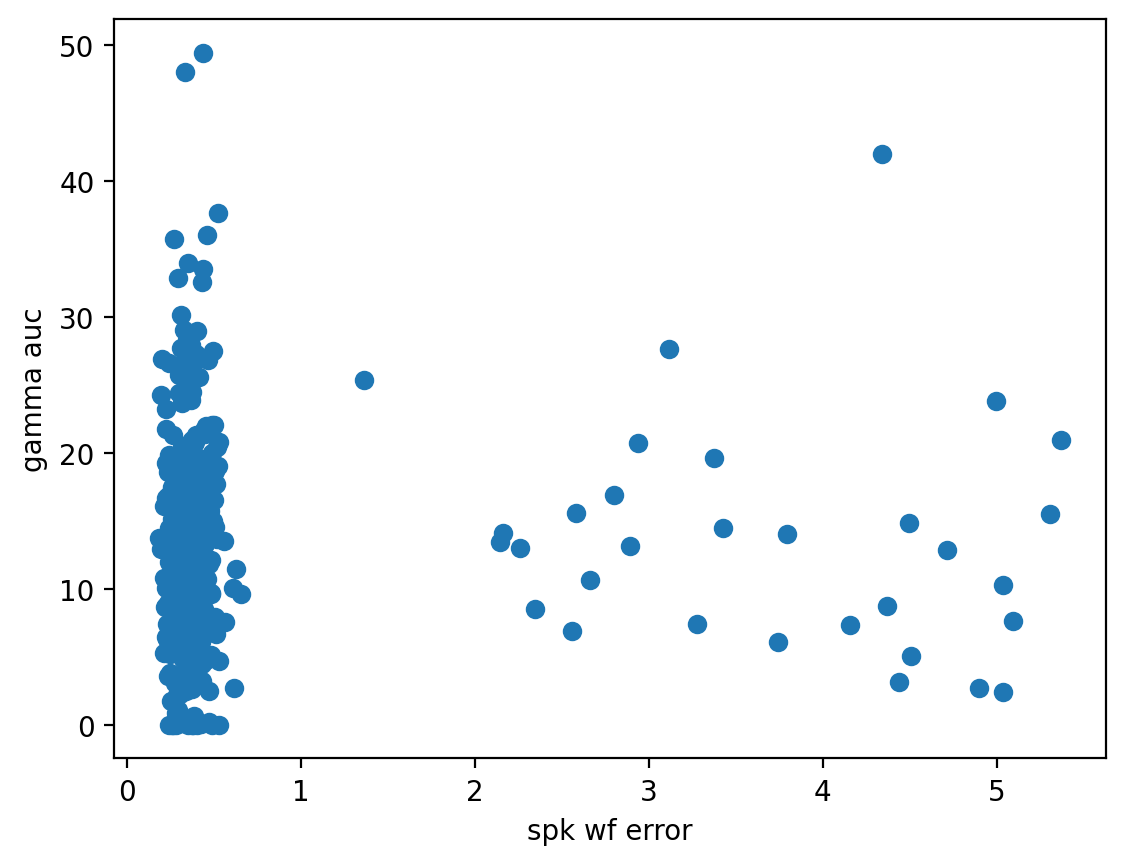

In [37]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['gamma_auc'])
plt.xlabel("spk wf error")
plt.ylabel("gamma auc")

Text(0, 0.5, 'aperiodic exponent')

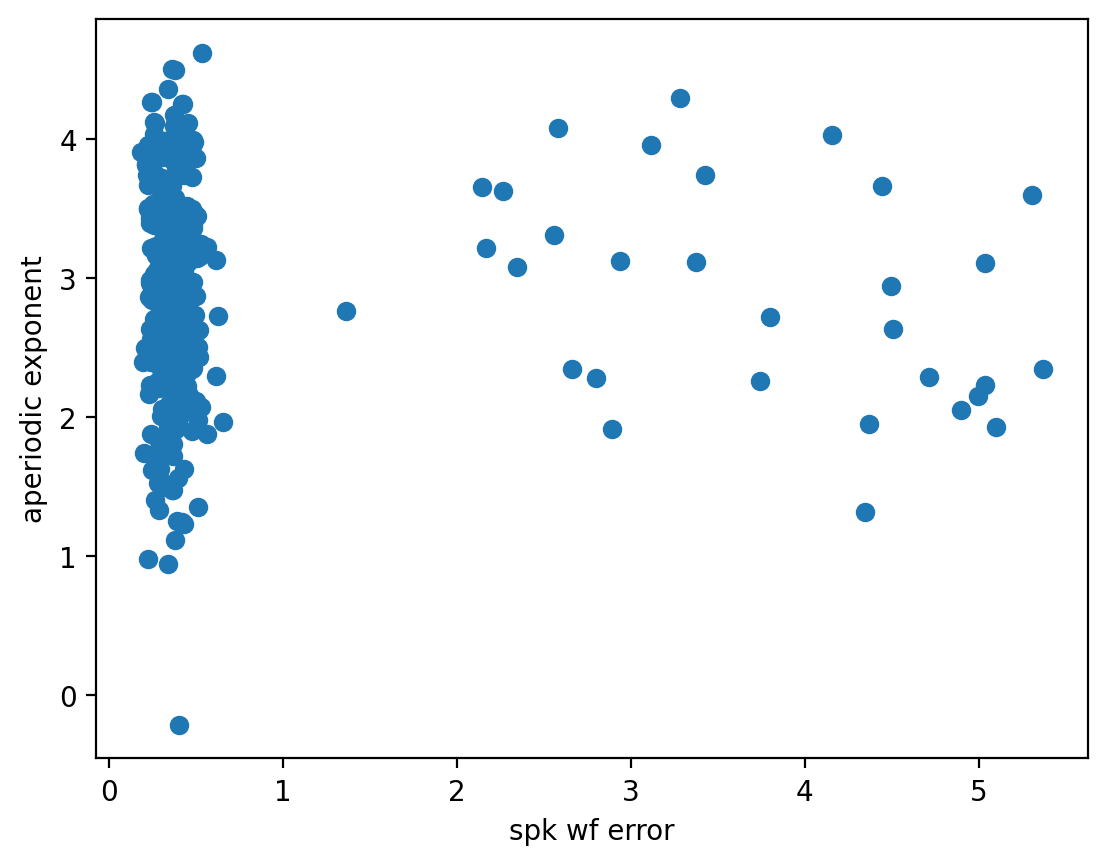

In [38]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['aperiodic_exponent'])
plt.xlabel("spk wf error")
plt.ylabel("aperiodic exponent")

## STEP 5: Build regression to predict per-spike error as a combination of the gamma AUC and the aperiodic exponent - RIP - didn't work

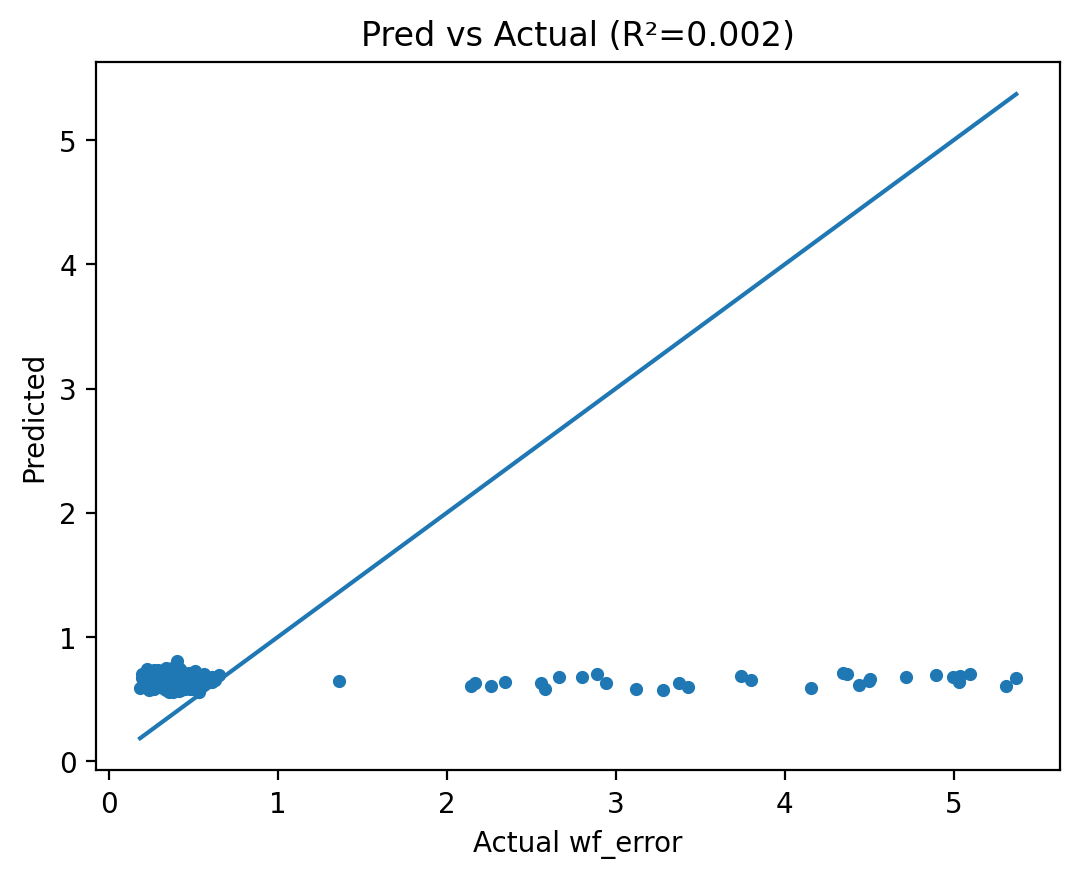

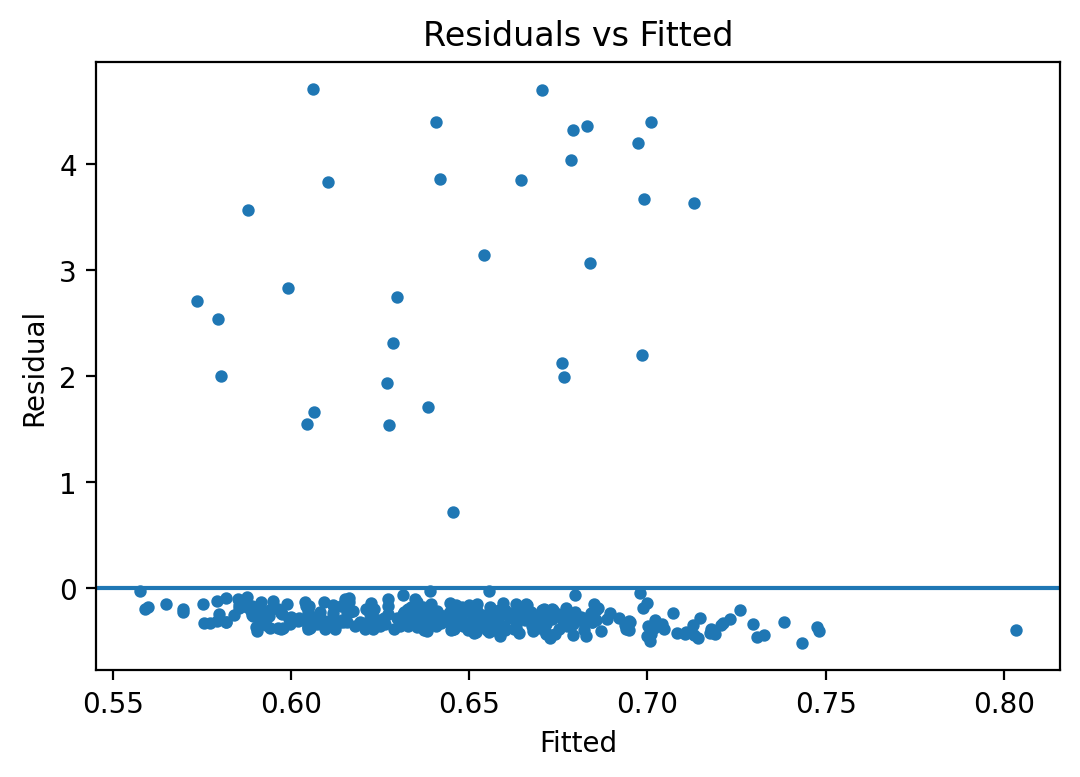

                        coef        se          z         P>|z|     ci_lo  \
const               0.645632  0.052727  12.244889  1.789212e-34  0.542290   
gamma_auc          -0.004904  0.059050  -0.083040  9.338195e-01 -0.120640   
aperiodic_exponent -0.040000  0.055771  -0.717217  4.732400e-01 -0.149309   

                       ci_hi  
const               0.748975  
gamma_auc           0.110833  
aperiodic_exponent  0.069309  


In [39]:
res = fit_linear_regression(
    spike_lfp_df,
    y_col="wf_error",
    x_cols=["gamma_auc", "aperiodic_exponent"],
    standardize=True,
    interactions=False,
    robust_se=True,
    do_cv=True,
    cv_splits=5,
    plot=True,
)
print(res["coefs"])


### STEP 6: See if AUC and aperiodic exponent correlate with spike params 

In [40]:
#create combined df with new LFP features and spike params 

#make sure the left DF has a 'spk_id' column to join on
spike_lfp_df_ = spike_lfp_df.copy()
if "spk_id" not in spike_lfp_df_.columns and "pk_id" in spike_lfp_df_.columns:
    spike_lfp_df_ = spike_lfp_df_.rename(columns={"pk_id": "spk_id"})

# select the feature columns you want from df_features (index by spk_id for a clean join)
feat_cols = [
    "ramp_amp",
    "inflection_time",
    "inflection_amp",
    "peak_amp",
    "peak_width",
    "peak_sharpness",
    "exp_lambda",
    "exp_const",
    "log_isi",
]
feat = df_features.set_index("spk_id")[feat_cols]

# left join by spk_id
spike_lfp_with_feats = spike_lfp_df_.join(feat, on="spk_id", how="left")




In [41]:
spike_lfp_with_feats

,spk_id,spk_times_ms,wf_error,win_idx,gamma_auc,aperiodic_exponent,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi
0,0,2.667479e+05,3.606945,66686.0,NaN,NaN,1.416220,0.52,5.370863,6.295294,0.60,0.043751,0.015726,-100.000000,2.219167
1,1,2.696710e+05,5.308446,67417.0,15.540539,3.599550,1.533453,1.72,3.874037,4.667276,0.82,0.090837,0.329459,1.627345,1.488625
2,2,2.726137e+05,5.096507,68153.0,7.675628,1.925618,2.366371,1.42,3.010957,4.096517,1.54,0.013247,0.324193,1.731115,1.623455
3,3,2.734009e+05,5.370463,68350.0,20.957855,2.347222,2.587793,0.80,4.747070,5.018727,0.50,-0.078035,0.237210,1.966579,1.877509
4,4,2.735865e+05,4.994218,68396.0,23.834440,2.149321,11.048626,1.52,2.315093,4.528403,2.92,0.091947,0.133589,1.852847,1.768579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,503,1.077949e+06,0.328527,269487.0,18.256562,1.496351,-0.263089,1.10,-0.346746,4.291560,1.02,0.152129,1.399263,-0.280565,1.397037
504,504,1.077974e+06,0.435337,269493.0,33.569279,3.286082,-1.365464,0.98,-3.484229,4.112964,2.36,0.165741,1.634414,-0.357630,1.881975
505,505,1.078051e+06,0.404213,269512.0,17.113340,3.107944,-0.969500,0.94,-2.524469,4.160575,1.56,0.229697,1.769301,-0.327425,1.547813
506,506,1.078133e+06,0.531411,269533.0,4.719227,4.618236,-1.659589,0.86,-4.149963,4.181082,3.96,0.242676,1.602404,-0.350285,1.522758


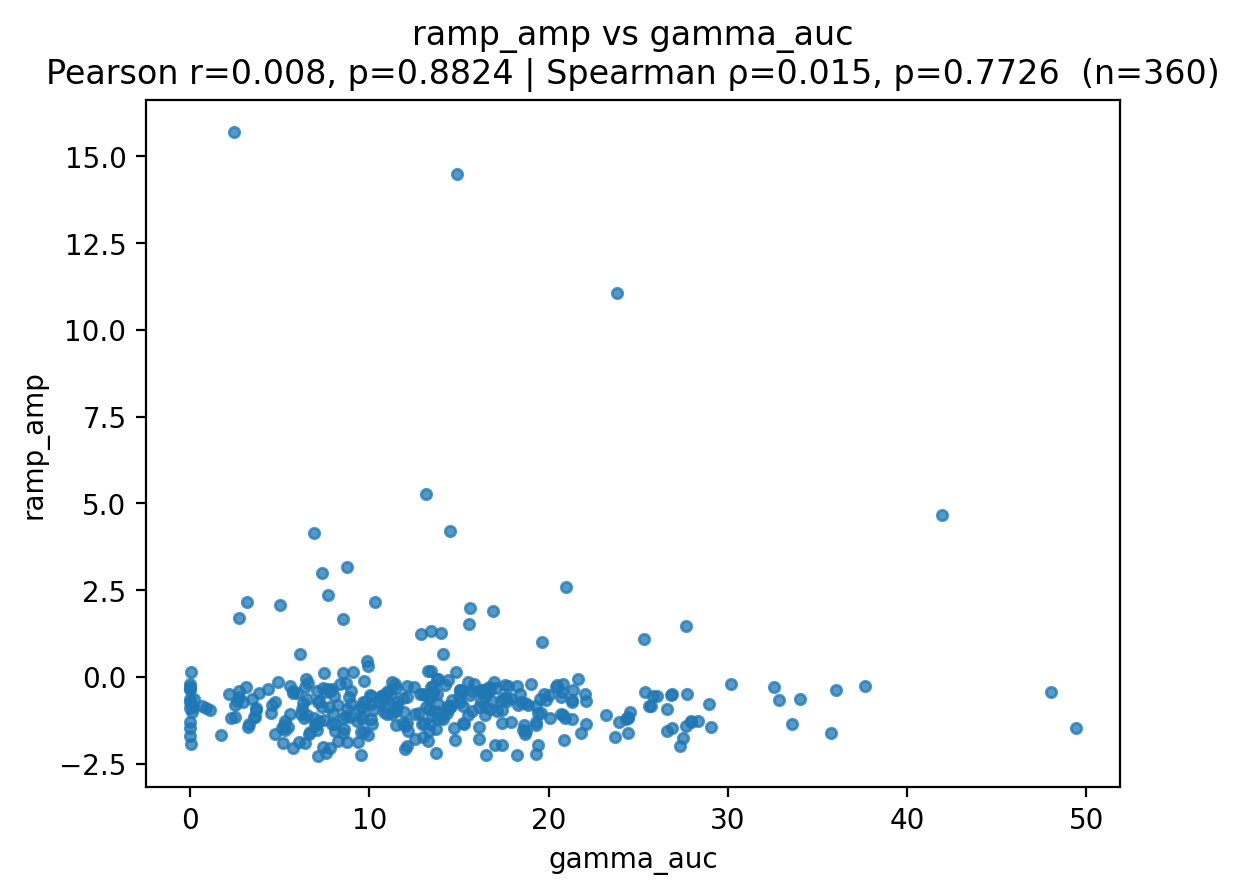

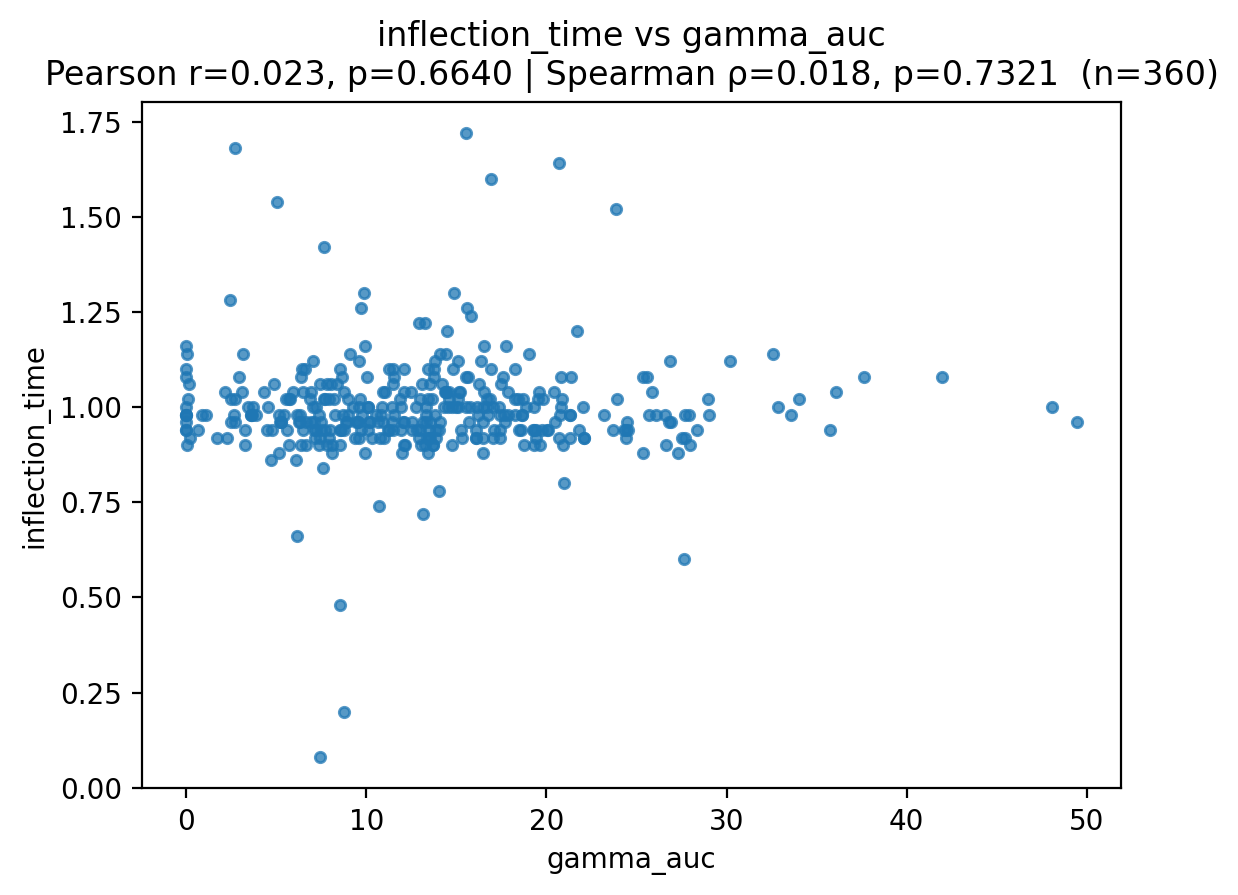

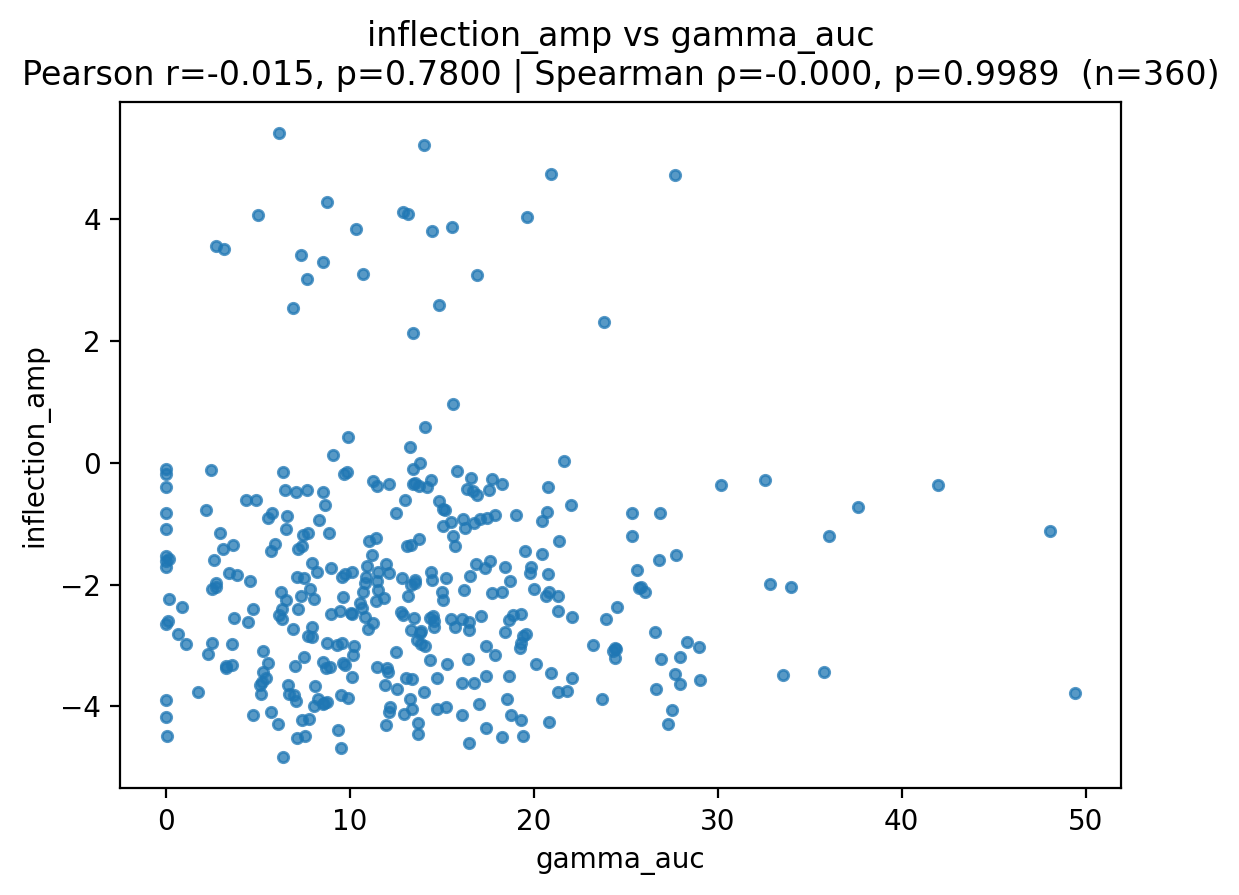

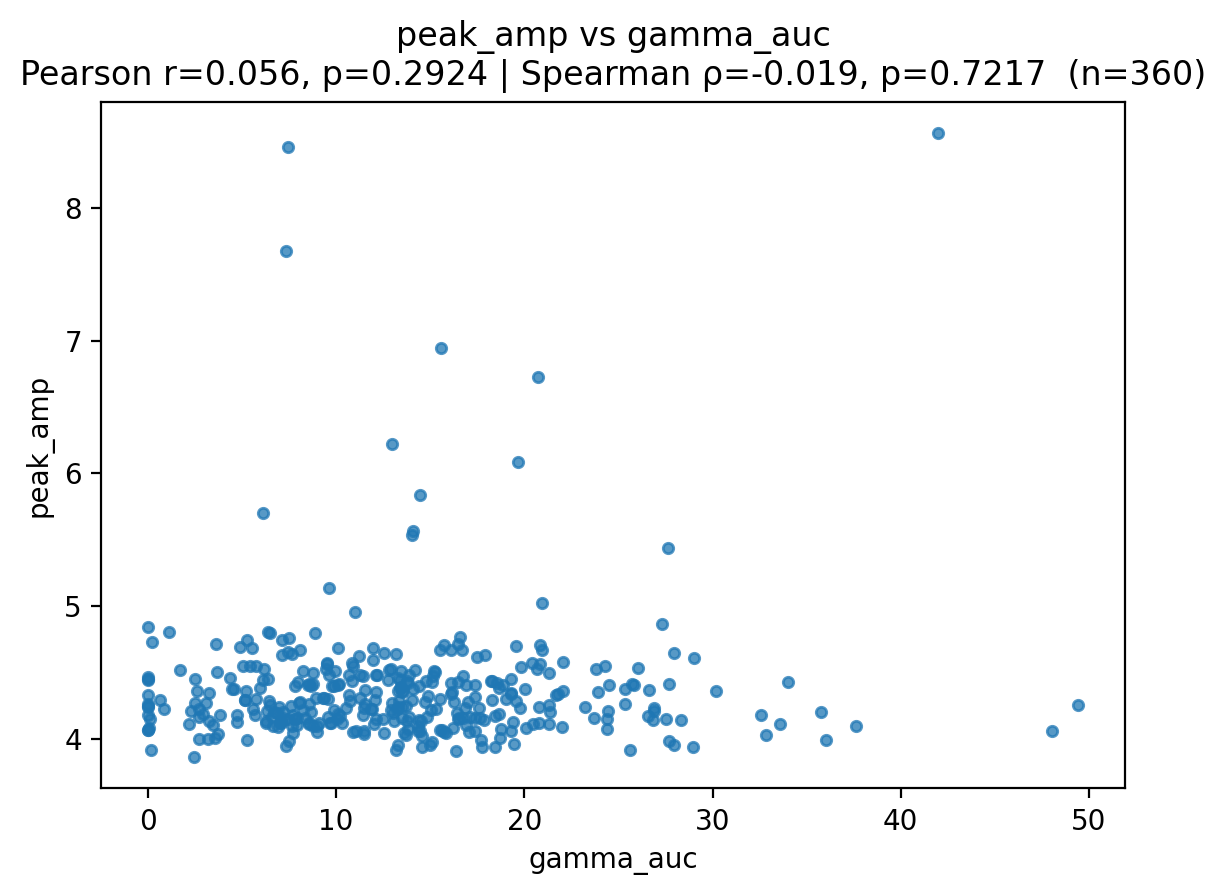

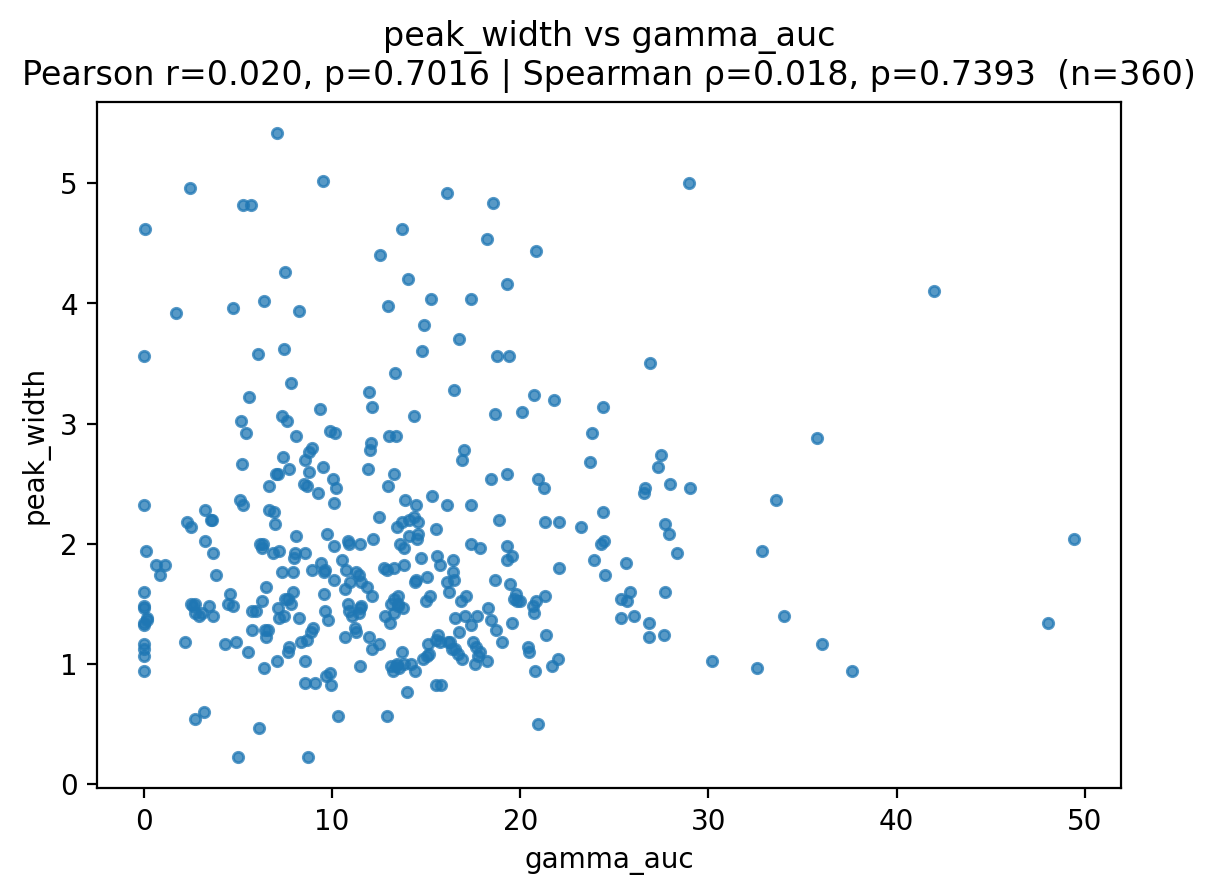

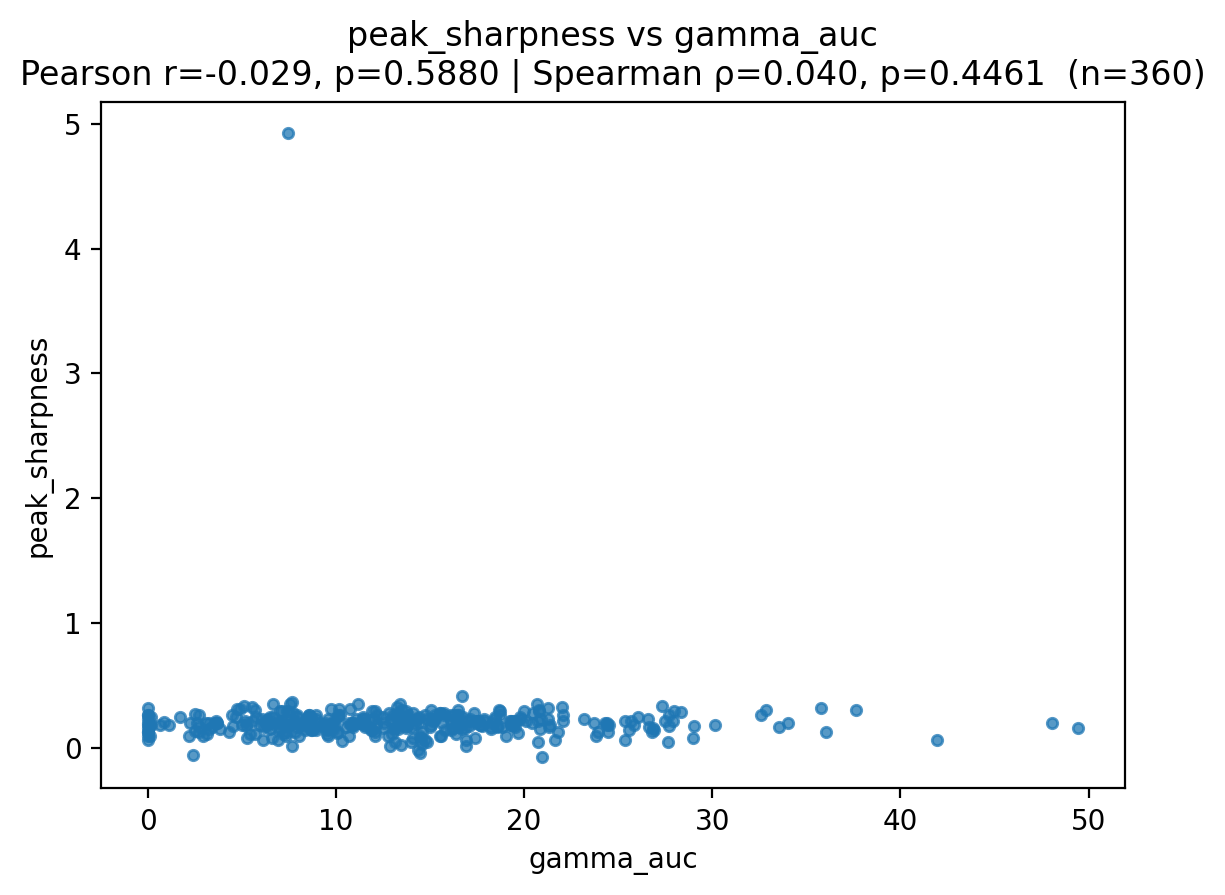

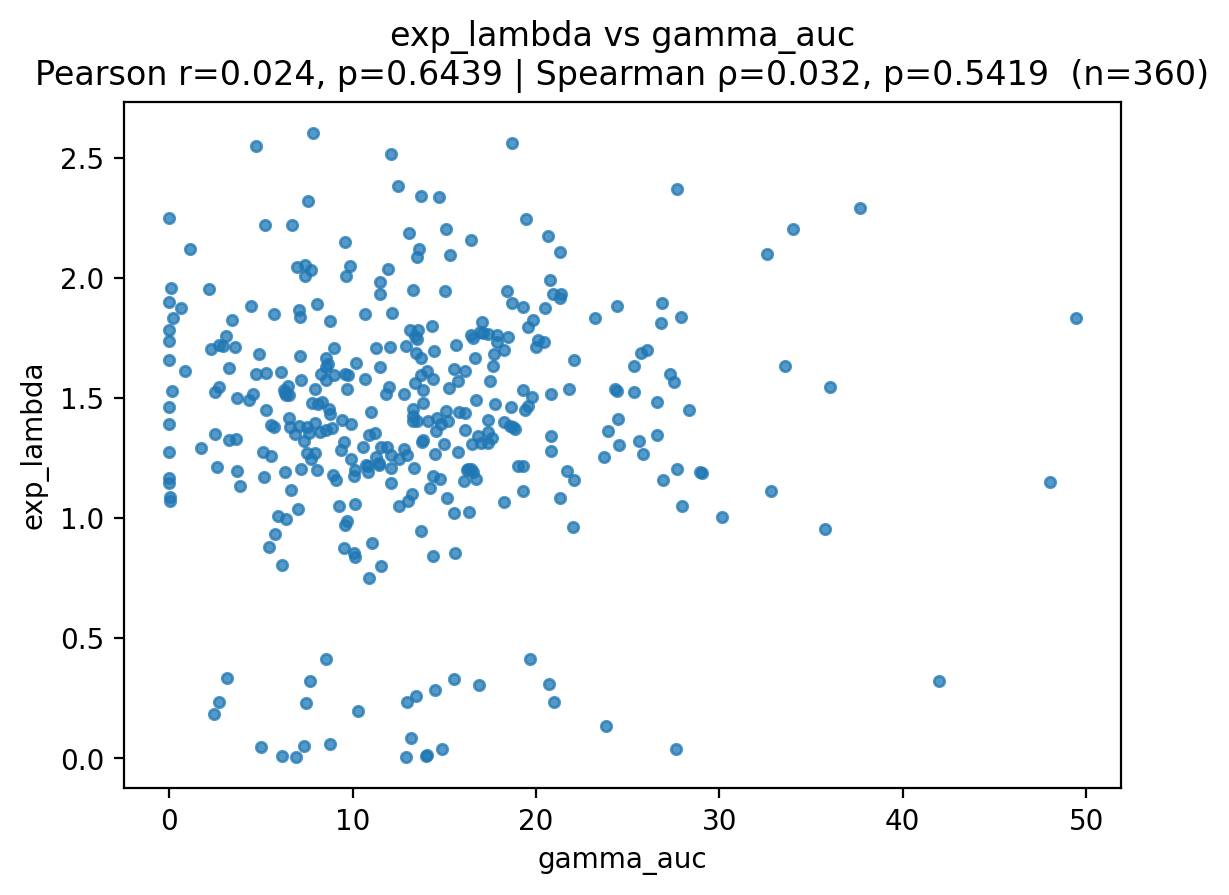

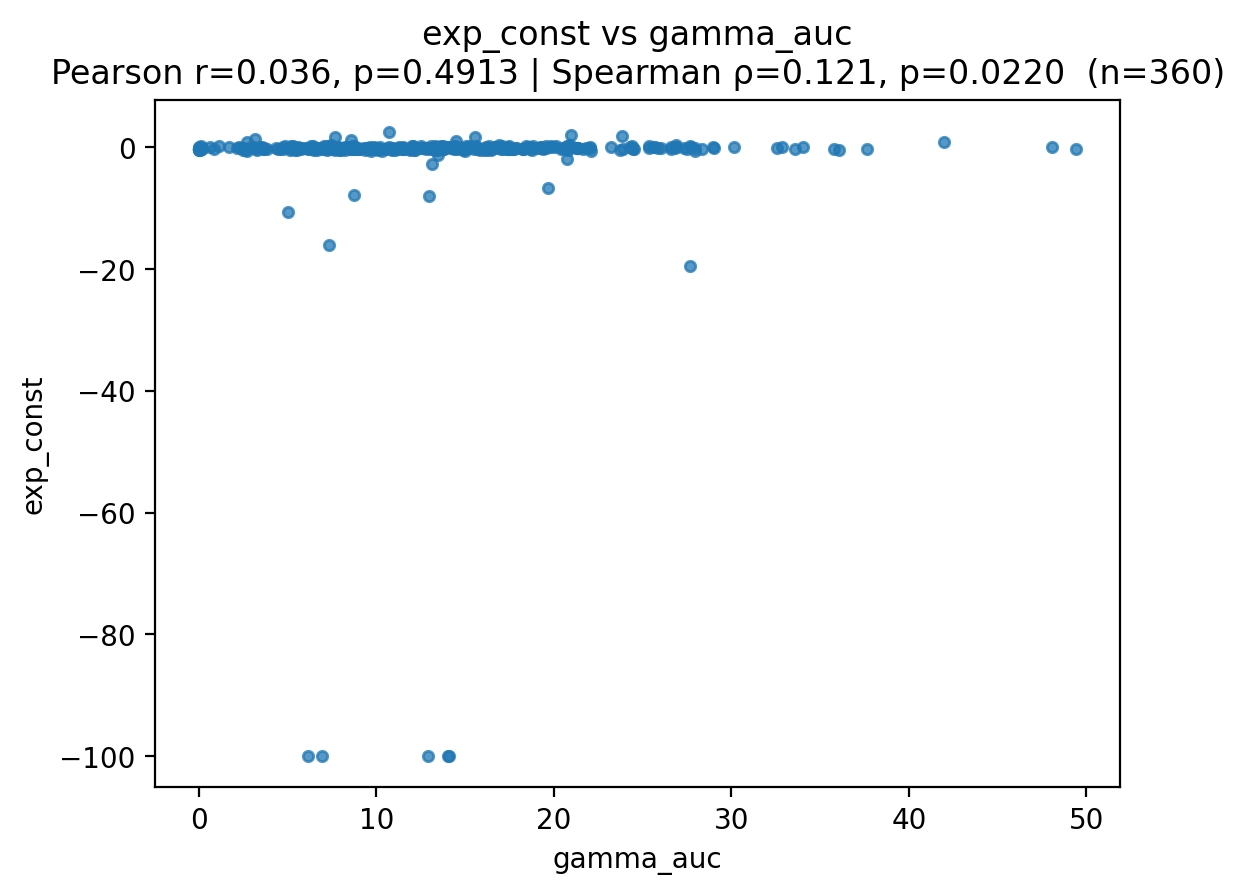

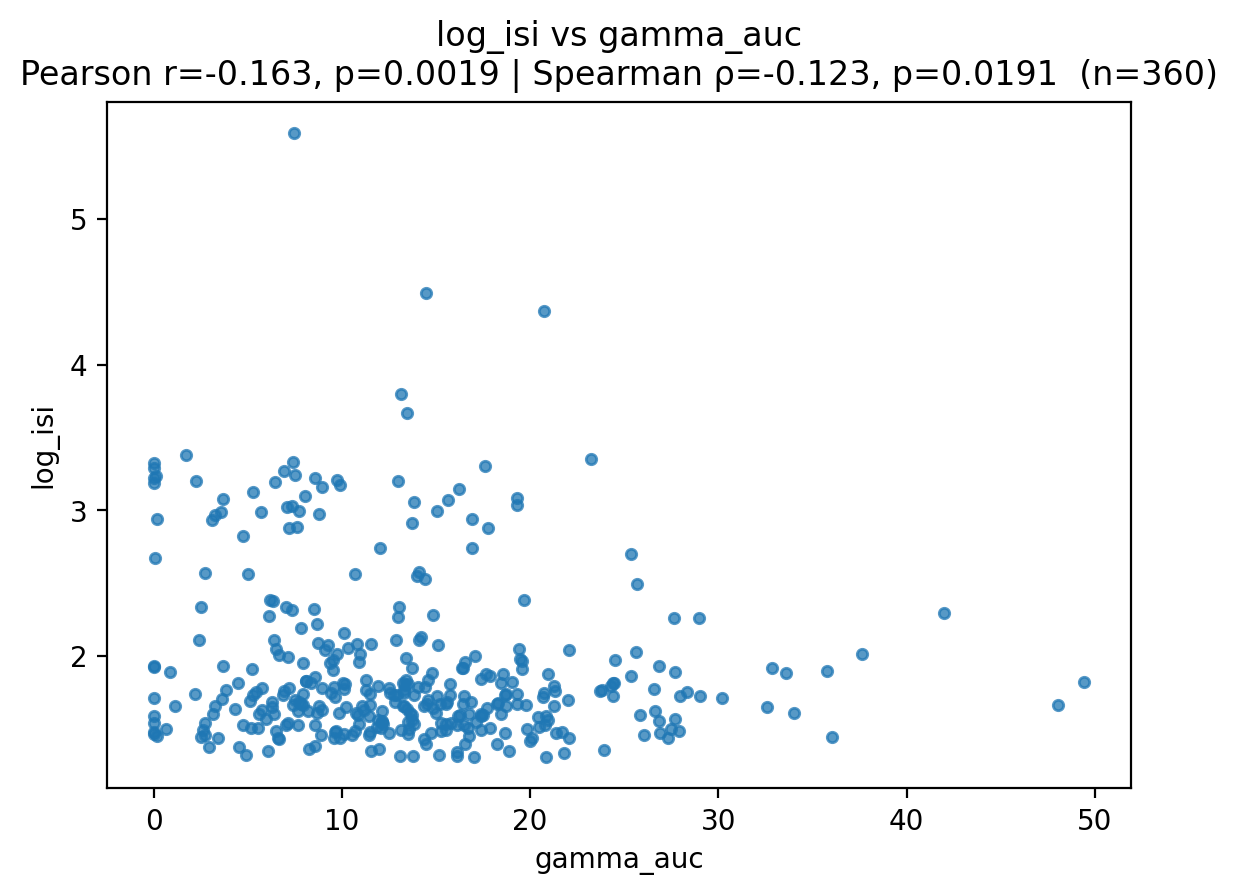

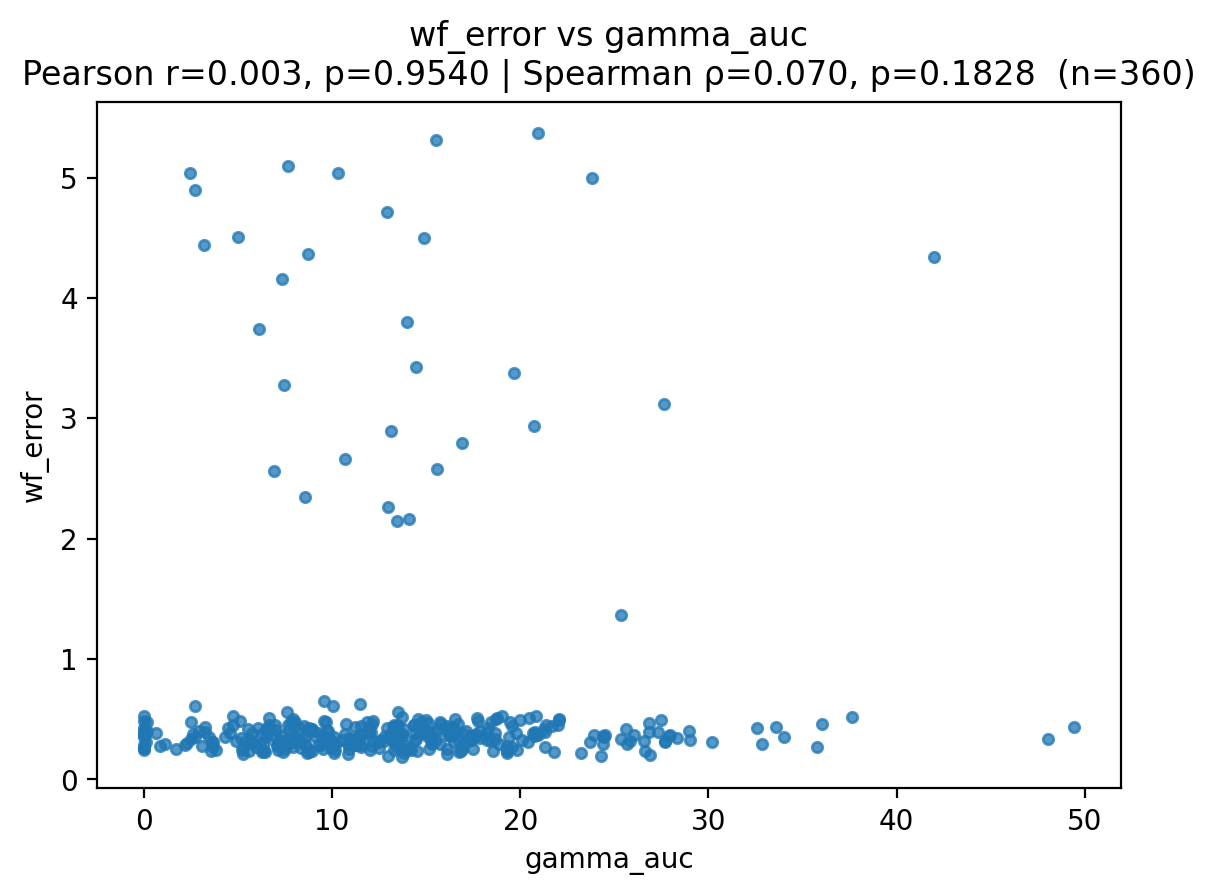

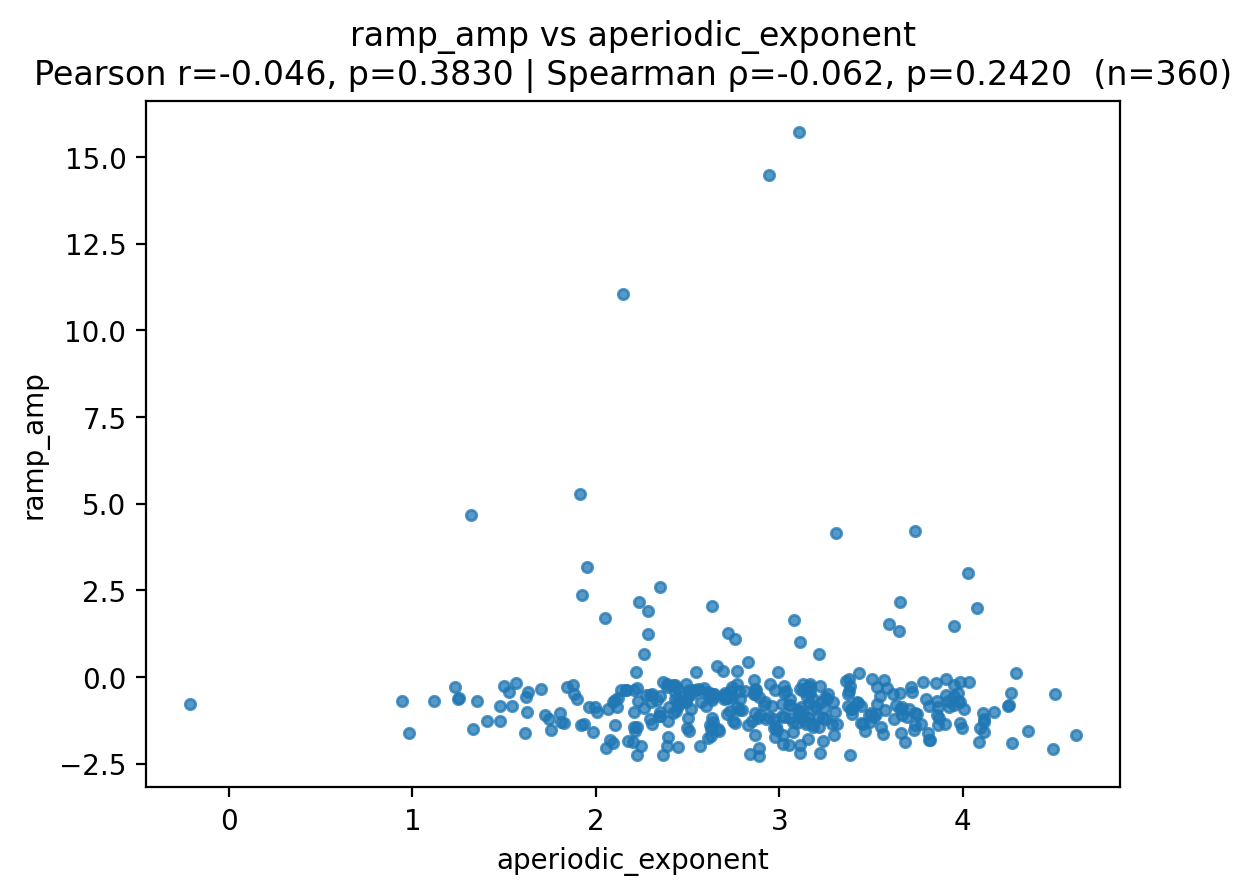

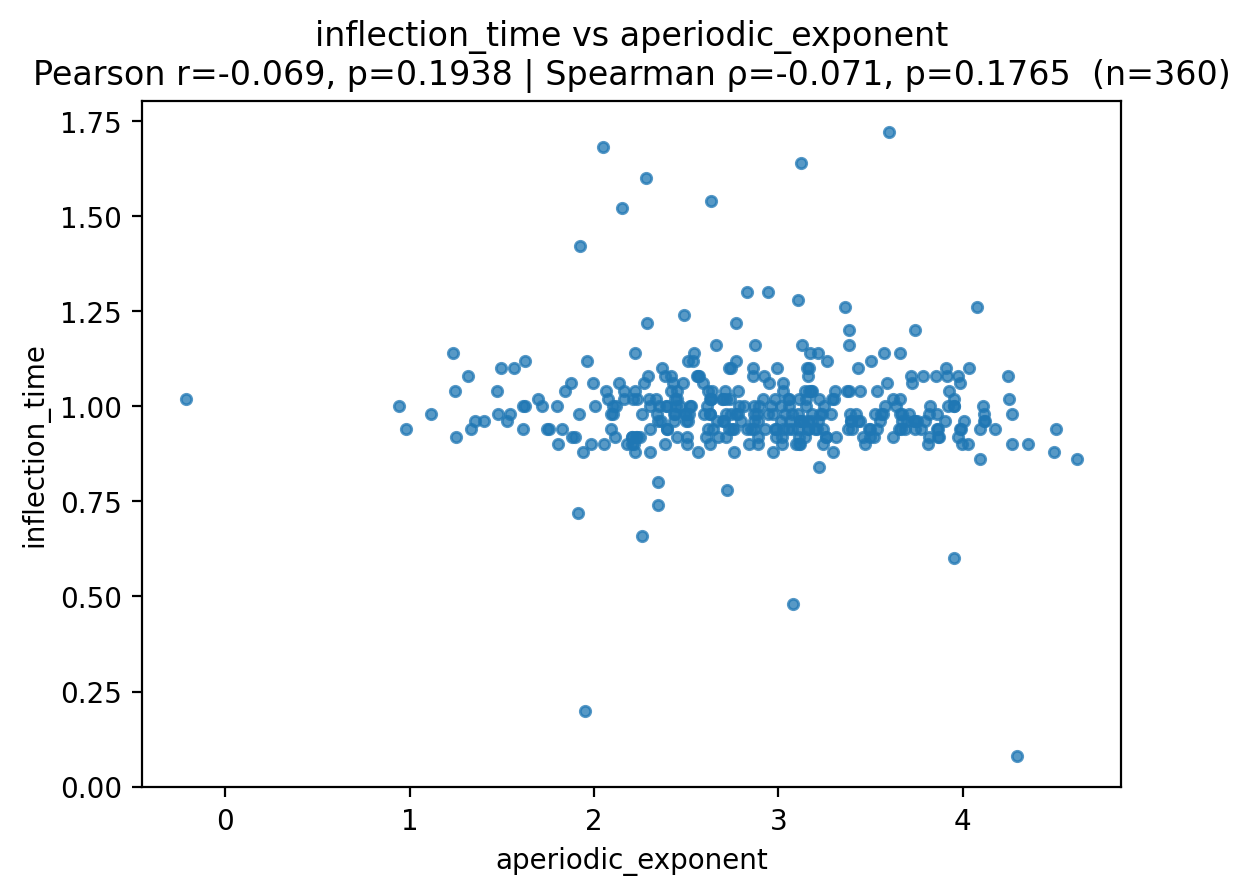

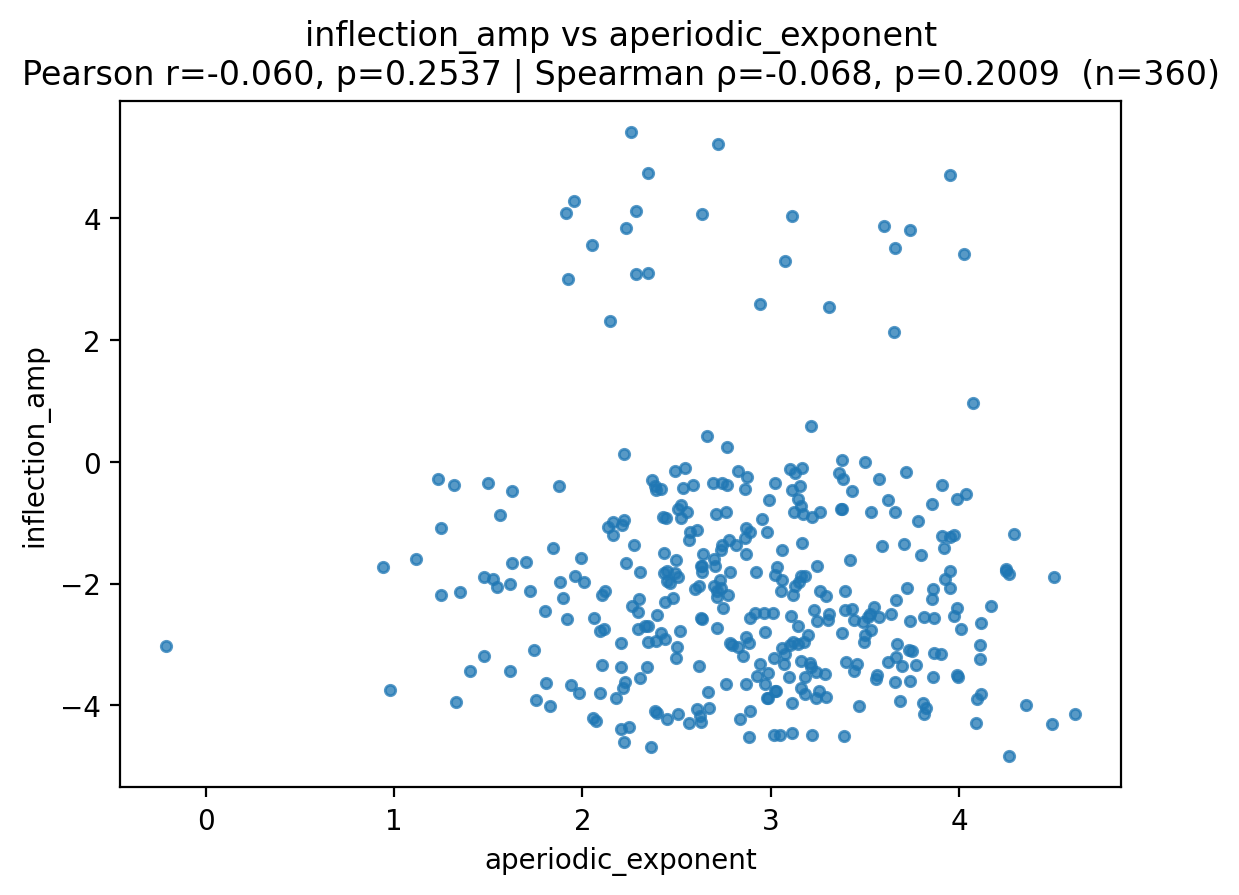

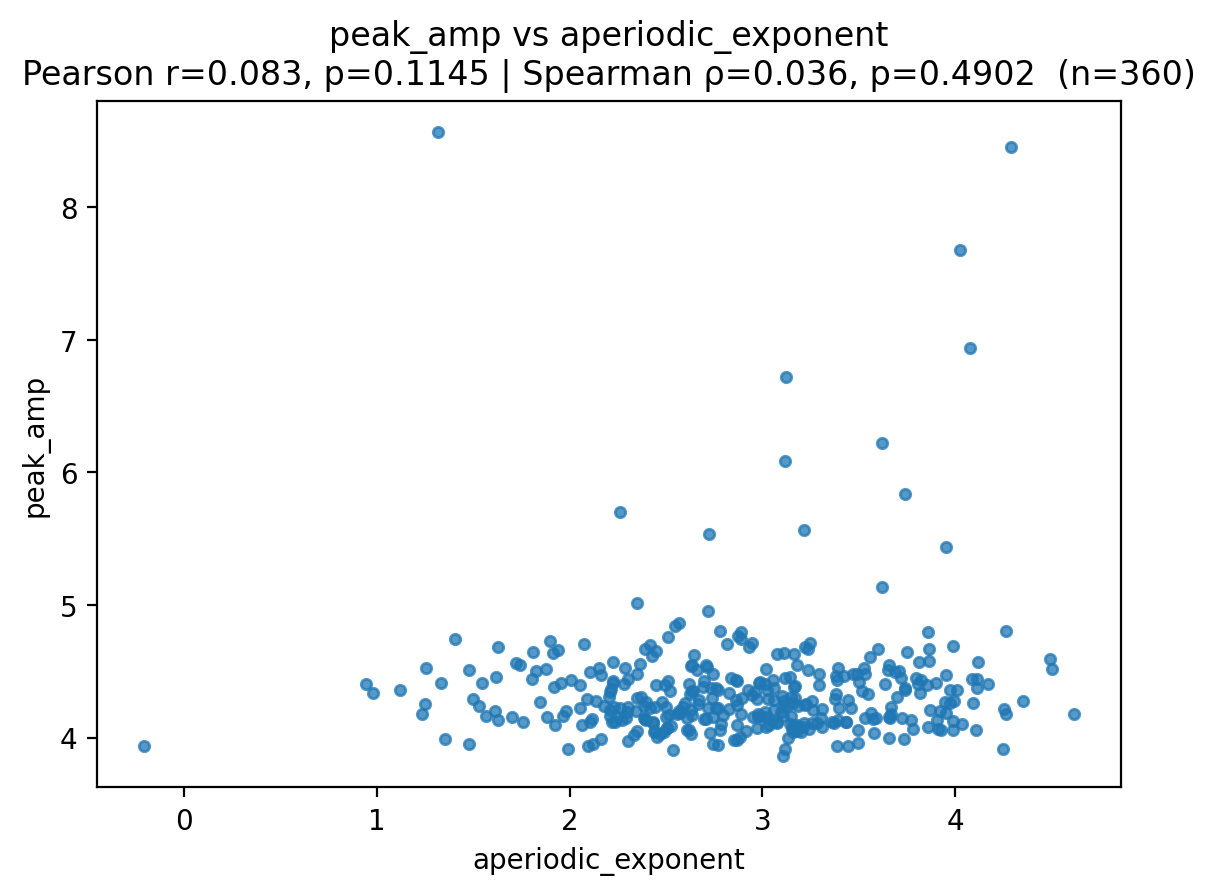

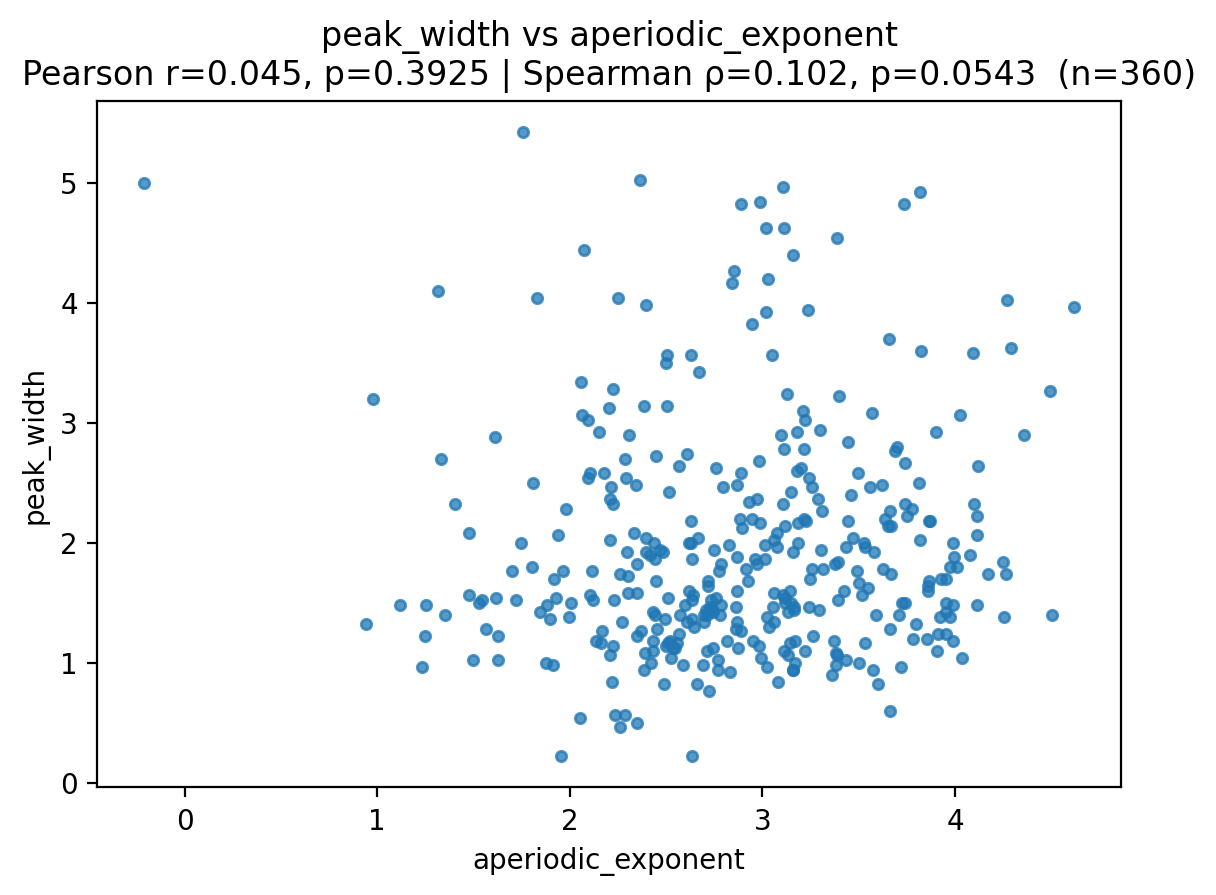

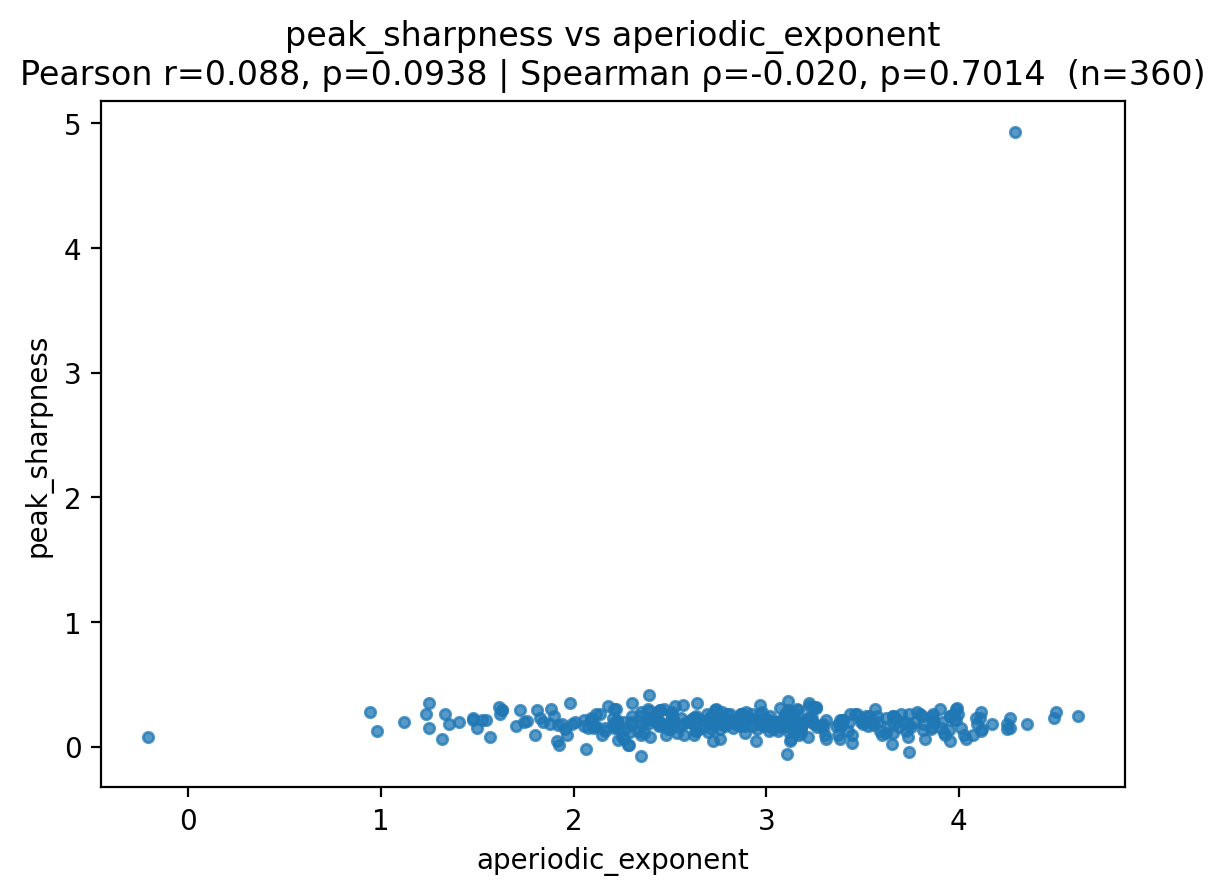

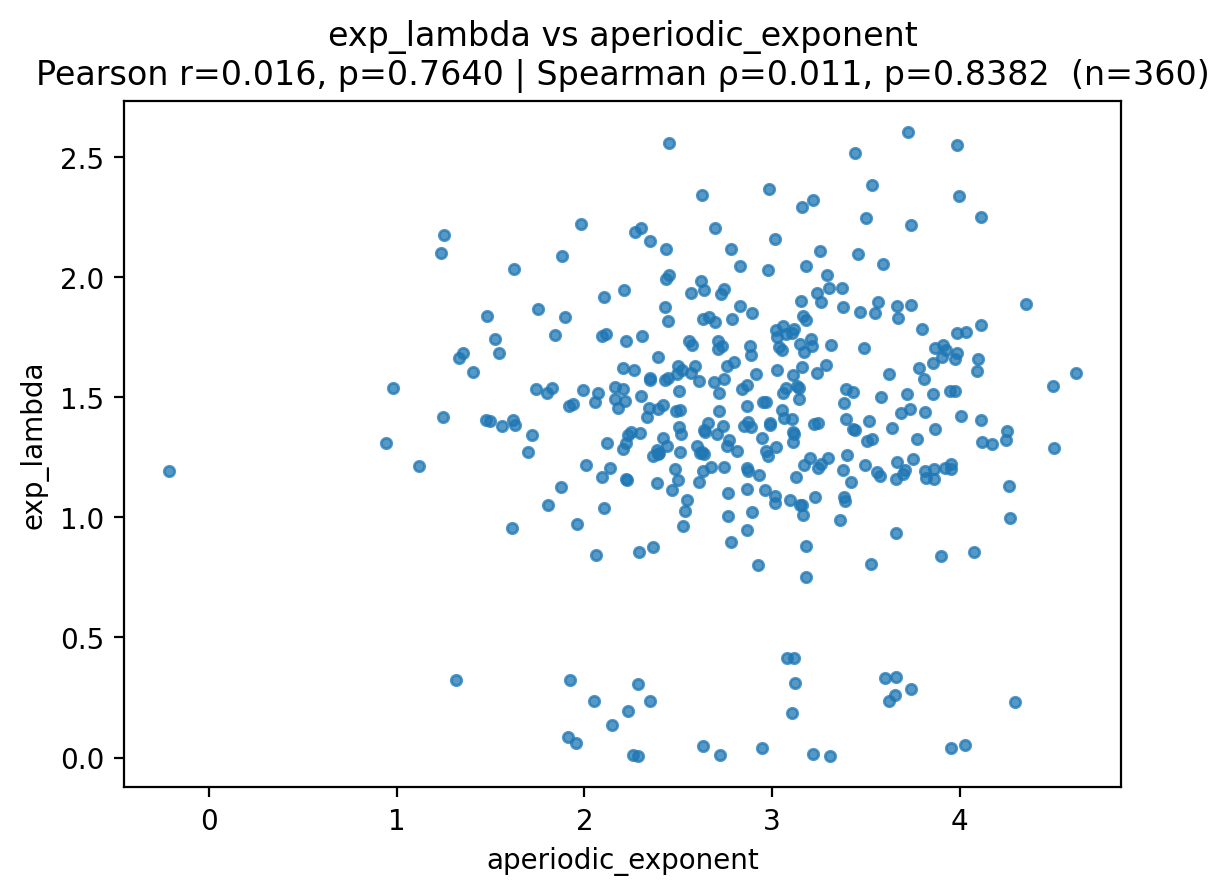

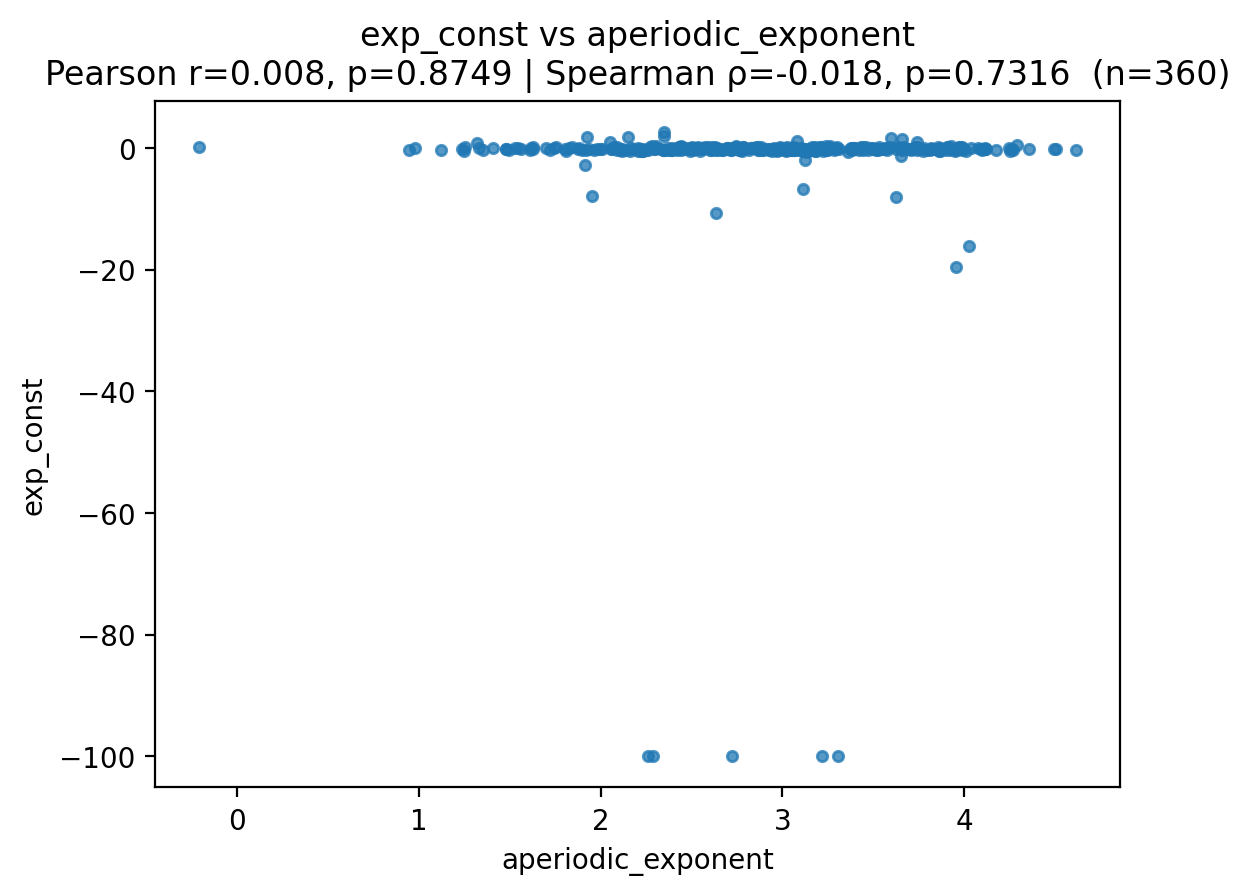

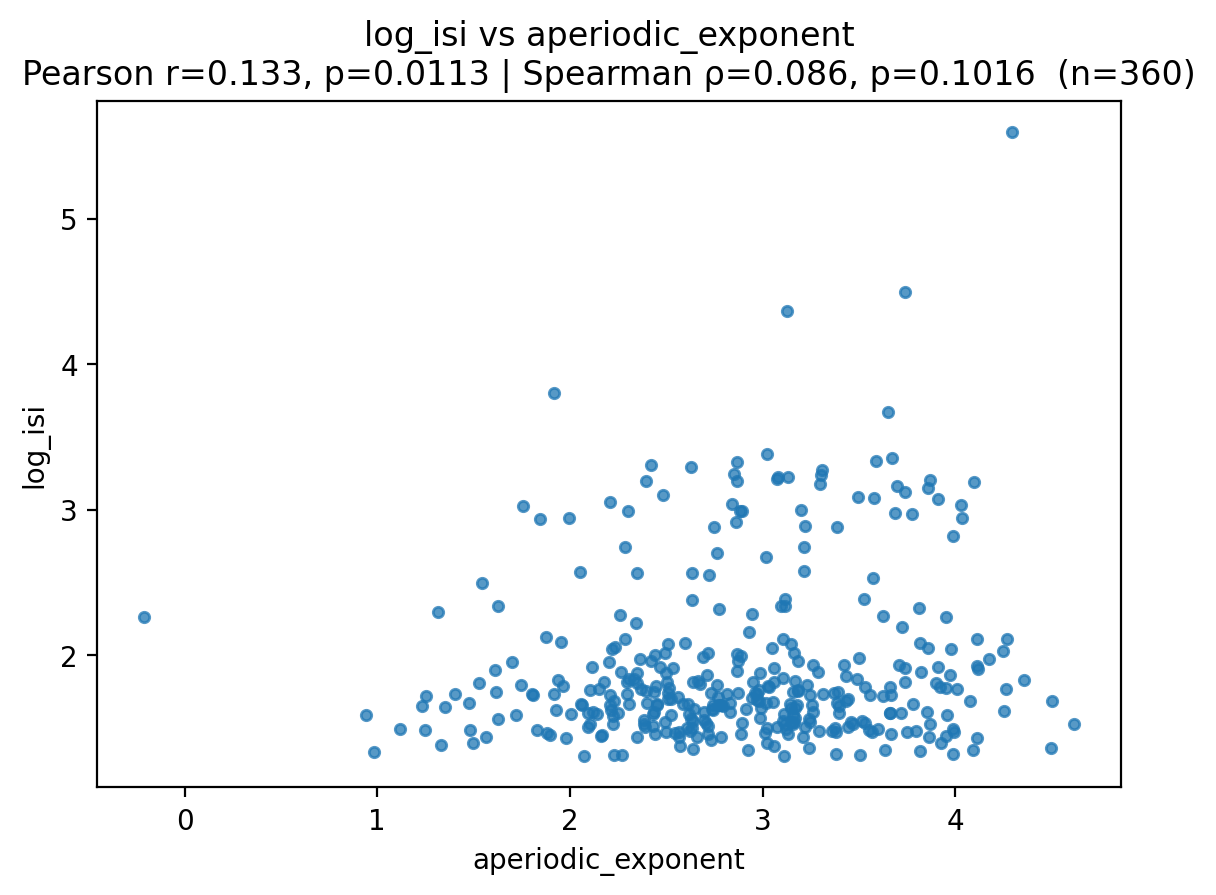

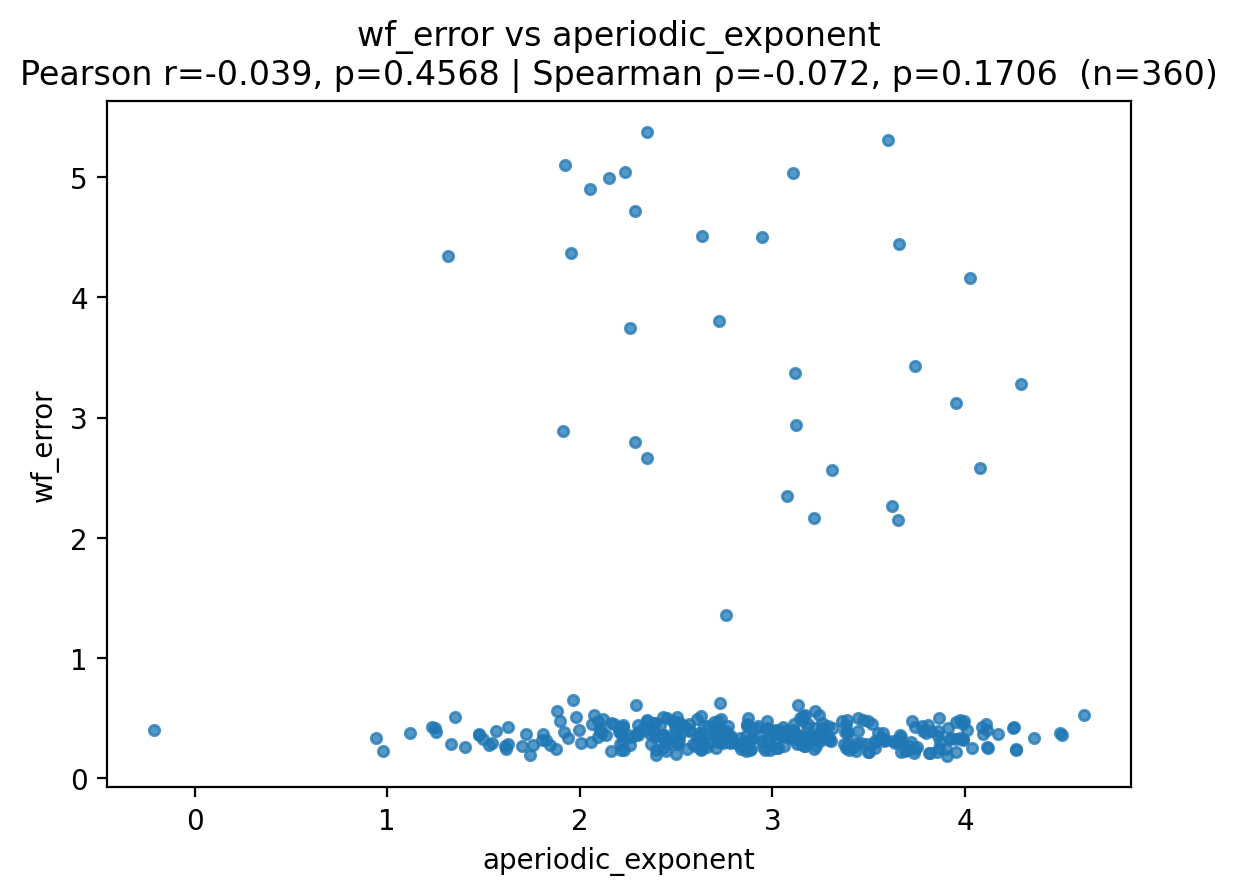

In [42]:
#look for correlations 

from scipy.stats import pearsonr, spearmanr

df = spike_lfp_with_feats  # your merged dataframe

lfp_feats   = ["gamma_auc", "aperiodic_exponent"]
spike_feats = [
    "ramp_amp","inflection_time","inflection_amp","peak_amp",
    "peak_width","peak_sharpness","exp_lambda","exp_const","log_isi","wf_error"
]

lfp_feats   = [c for c in lfp_feats   if c in df.columns]
spike_feats = [c for c in spike_feats if c in df.columns]

def fmt_p(p, decimals=4):
    thresh = 10**(-decimals)
    return f"< {thresh:.{decimals}f}" if p < thresh else f"{p:.{decimals}f}"

for x in lfp_feats:
    for y in spike_feats:
        d = df[[x, y]].dropna()
        n = len(d)
        if n < 3:
            continue

        r_p, p_p = pearsonr(d[x], d[y])
        r_s, p_s = spearmanr(d[x], d[y])

        fig, ax = plt.subplots(figsize=(5.8, 4.6))
        ax.scatter(d[x].to_numpy(), d[y].to_numpy(), s=14, alpha=0.75)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(
            f"{y} vs {x}\n"
            f"Pearson r={r_p:.3f}, p={fmt_p(p_p)} | "
            f"Spearman ρ={r_s:.3f}, p={fmt_p(p_s)}  (n={n})"
        )

       

        plt.tight_layout()
        plt.show()
